### packages

In [3]:
import warnings
warnings.filterwarnings('ignore')

# %matplotlib inline
from pathlib import Path
from time import sleep

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm as tqdm_bar
import time as _time
import random
import tempfile
from scipy.optimize import curve_fit

from orenge.general import *


# Experiment controls -------------------------------------------------------------

import qcodes as qc
from qcodes.dataset import (
    Measurement,
    initialise_or_create_database_at,
    load_or_create_experiment,
)
from qcodes.logger import start_all_logging
start_all_logging()
import qcodes.instrument_drivers.stanford_research as stanford_research

from spinapi import *

import pyvisa # for the SR830 lockin amplifier and Anritsu RF signal generator
pyvisa_rm = pyvisa.ResourceManager()

import os
import sys
ultolib_dir = os.path.dirname('C:/Users/nv-group02/Desktop/NV-Lab/ultolib')
sys.path.insert(0, ultolib_dir)
from ultolib import (anritsu, korad, spincore)
from ultolib.spincore import pulse

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\nv-group02\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\nv-group02\.qcodes\logs\260429-19920-qcodes.log


In [4]:
print(qc.__version__)

0.57.0


### template

In [ ]:

################################################################################
#
# Define and allocate temporary and output arrays
#

# log.info("Starting the loop of %d iterations" % num_delay_times)

# Tdelays_arr = np.linspace(0, MaxTdelay, num_delay_times)
# Tdelays_arr = np.logspace( np.log10(5*us), np.log10(2*ms), num_delay_times)
                   
# Tstep = MaxTdelay / num_delay_times
# LIstep = Tstep / num_data_points

################################################################################
#
# Setup and initialise the instruments : 
#   PulseBlaster, SignalGenerator, LockInAmplifier
#   pb, sg, lia are handles to our wrapper classes - not used much actually
#

# Initializse PulseBlaster
pb_set_debug(0)
pb_select_board(0)
if pb_init() != 0:
	print("Error initializing board: %s" % pb_get_error())
	input("Please press a key to continue.")
	exit(-1)
# Configure the core clock
pb_core_clock(500)

#Initialize Signal Generator
sg = pyvisa_rm.open_resource('ASRL4::INSTR')
sg.read_termination = '\r\n'
sg.baud_rate = 9600

# Initialize LockIn 
lia = pyvisa_rm.open_resource('ASRL5::INSTR')
lia.baud_rate=9600
lia.data_bits=8
lia.read_termination = '\r'
lia.write_termination = '\r\n'

################################################################################
#
# Loops in which the pulse sequence parameters change go here !
#

########################################
#
# Define some pulse sequence parameters
#
# Note that the units : ms, us are defined as multipliers in SpinCorePyWrapper 
#   all times are expected to be in ns = nanoseconds
#
Tref = 2.5*ms
Tlaser = 4*us
Tmw = 3*us

# Tmw_min = 2*us
# Tmw_max = 5*ms
# num_mw_times = 9

Tpadding = 0.25*us

# number of times sequences are repeated in each Tref
Nrepeat = 250
if( Tref / Nrepeat < Tlaser + Tmw + Tpadding ):
    print("Error in pulse sequence, Treference is too short")
    input("Please press a key to continue.")
    exit(-1)

# Frequencies are all in GHz
freq_min = 2.77
freq_max = 2.97
num_freqs = 128

freq_array = np.linspace(freq_min, freq_max, num_freqs)

# initialize output array(s)
vlockin_array = np.zeros(num_freqs)
    
lockin_settle_time = 0.2  # units are seconds, used by Python sleep() function

#-------------------------------------------------------------------------------
# Set signal generator output level and turn on before the loop
#
mwpower = -6
sg.write(f'OLVL {mwpower} DBM')
sg.write('LVL ON')


# loop over something...
for n in range(num_freqs):

    # update variables for this iteration    
    freq = freq_array[n]
    
    #---------------------------------------------------------------------------
    #
    # Program the updated pulse program 
    #
    # Define binary strings for each output channel 
    #   Note : here we use the first four channels (read right to left) for instrument control
    #          and repeat those on channels 5-8 to monitor on an oscilloscope
    #
    reference = 0b00010001
    laser     = 0b00100010
    mw_i      = 0b01000100
    mw_q      = 0b10001000
    zeros     = 0b00000000

    pb_start_programming(PULSE_PROGRAM)


    # Sanity check the parameters
    if( Tref / Nrepeat < Tlaser + Tmw + Tpadding ):
        print("Error in PulseSeq_ODMR_pulsed.")
        print("  Treference is too short for requesed repetitions Nrepeat")
        input("Please press a key to continue.")
        exit(-1)

    # time between laser and mw pulses
    Twait = Tref / Nrepeat - Tlaser - Tmw - Tpadding

    # Initiate a pulse program on the PulseBlaster
    pb_start_programming(PULSE_PROGRAM)

    # reference high
    start = pb_inst_pbonly(reference + laser, Inst.CONTINUE, 0, Tlaser)
    pb_inst_pbonly(reference, Inst.CONTINUE, 0, Twait)
    pb_inst_pbonly(reference + mw_i, Inst.CONTINUE, 0, Tmw)
    if( Nrepeat > 1 ):
        loop_high = pb_inst_pbonly(reference, Inst.LOOP, int(Nrepeat-1), Tpadding)
        pb_inst_pbonly(reference + laser, Inst.CONTINUE, 0, Tlaser)
        pb_inst_pbonly(reference, Inst.CONTINUE, 0, Twait)
        pb_inst_pbonly(reference + mw_i, Inst.END_LOOP, loop_high, Tmw)
    pb_inst_pbonly(reference, Inst.CONTINUE, 0, Tpadding)
    
    # reference low
    pb_inst_pbonly(laser, Inst.CONTINUE, 0, Tlaser)
    if( Nrepeat > 1 ):
        loop_low = pb_inst_pbonly(zeros, Inst.LOOP, int(Nrepeat-1), Tref / Nrepeat - Tlaser)
        pb_inst_pbonly(laser, Inst.END_LOOP, loop_low, Tlaser)
    pb_inst_pbonly(zeros, Inst.BRANCH, start, Tref / Nrepeat - Tlaser)

    pb_stop_programming()

    # reset the signal generator frequency 
    sg.write(f'FREQ {freq} GHZ')

    #---------------------------------------------------------------------------
    #
    # Trigger the PulseBlaster to run our sequence
    #
    
    # pb_reset()   # reset everything; this must be called before pb_start
    pb_start()   # start the sequence running

    sleep(0.1)   # wait a moment to ensure the pulse program is running


    #---------------------------------------------------------------------------
    # Python code to do data acquisition while the current pulse sequence runs
    #

    sleep(lockin_settle_time)
    
    # acquire lockin signal [I] and convert to [pA]
    R = float(lia.query('OUTP? 3')) * 1e12

    vlockin_array[n] = R

#    print("freq = " + f'{freq:6.4f}' + "    Vlockin=" + f'{R:8.2f}' )
    
    pb_stop()    # stop running the pulse sequence (leave communication open)

#
# end loop

pb_close()   # close communication with the PulseBlaster

################################################################################
#
# Process and plot the output
#
print(f'Tlaser = {Tlaser}  Tmw = {Tmw}')
plt.plot(freq_array, vlockin_array)


In [ ]:
print('V_B = 0.0 V')
print('lockin time constant = 30 ms')
print(f'lockin wait time = {lockin_settle_time} s')
print('mwpower = {mwpower} dBm')
plt.plot(freq_array, vlockin_array)

In [ ]:
print('V_B = 0.0 V')
print('lockin time constant = 30 ms')
print(f'lockin wait time = {lockin_settle_time} s')
print('mwpower = {mwpower} dBm')
plt.plot(freq_array, vlockin_array)

In [ ]:
print('V_B = 0.0 V')
print('lockin time constant = 100 ms')
print(f'lockin wait time = {lockin_settle_time} s')
print('mwpower = {mwpower} dBm')
plt.plot(freq_array, vlockin_array)

In [ ]:
print('V_B = 2.0 V')
print('lockin time constant = 30 ms')
print(f'lockin wait time = {lockin_settle_time} s')
print('mwpower = {mwpower} dBm')
plt.plot(freq_array, vlockin_array)

In [ ]:
print('V_B = 2.0 V')
print('lockin time constant = 30 ms')
print(f'lockin wait time = {lockin_settle_time} s')
print('mwpower = {mwpower} dBm')
plt.plot(freq_array, vlockin_array)

In [ ]:
print('V_B = 2.0 V')
print('lockin time constant = 30 ms')
print(f'lockin wait time = {lockin_settle_time} s')
print('mwpower = {mwpower} dBm')
plt.plot(freq_array, vlockin_array)

In [ ]:
print('V_B = 1.0 V')
print('lockin time constant = 30 ms')
print(f'lockin wait time = {lockin_settle_time} s')
print('mwpower = {mwpower} dBm')
plt.plot(freq_array, vlockin_array)

In [ ]:
print('V_B = 0.0 V')
print('lockin time constant = 30 ms')
print(f'lockin wait time = {lockin_settle_time} s')
print('mwpower = {mwpower} dBm')
plt.plot(freq_array, vlockin_array)

### iter 1 (4/13/26)

#### instruments

In [2]:
# Reset the kernel in any other open notebook before running this cell.
pulse_blaster = spincore.PulseBlasterESRPRO(name='pulse_blaster', board_number=0)
pulse_blaster.core_clock(500)   # 500 MHz -> 2 ns timing resolution

lock_in_amp = stanford_research.SR830(
    name='lock_in_amp',
    address='ASRL5::INSTR',
    terminator='\r',
)

microwave_src = anritsu.MG3681A(
    name='microwave_src',
    address='ASRL4::INSTR',
    terminator='\r\n',
)

microwave_src.output_level_unit('dBm')
microwave_src.IQ_modulation('EXT')   # CH2 of PulseBlaster gates the MW via I-input
microwave_src.pulse_modulation('EXT')   # sends PMO EXT to the Anritsu
microwave_src.power(-6)              # -6 dBm: matches template (Experiment_ODMR.ipynb, template cell)
microwave_src.output('OFF')          # DO NOT turn on until antenna is connected

pulse_blaster.stop()

2026-04-13 15:18:32,237 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ c:\Users\nv-group02\anaconda3\envs\mqst\Lib\site-packages\qcodes\instrument\instrument_base.py:188: QCoDeSDeprecationWarning: Parameter ch1_databuffer on instrument lock_in_amp does not correctly pass kwargs to its baseclass. A Parameter class must take `**kwargs` and forward them to its baseclass.
  warnings.warn(

2026-04-13 15:18:32,287 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ c:\Users\nv-group02\anaconda3\envs\mqst\Lib\site-packages\qcodes\instrument\instrument_base.py:188: QCoDeSDeprecationWarning: Parameter ch2_databuffer on instrument lock_in_amp does not correctly pass kwargs to its baseclass. A Parameter class must take `**kwargs` and forward them to its baseclass.
  warnings.warn(



Connected to: Stanford_Research_Systems SR830 (serial:s/n32132, firmware:ver1.07) in 0.28s
Connected to: ANRITSU MG3681A (serial:6100146424, firmware:3.03) in 0.13s


0

#### timing params

In [3]:
# All values from Experiment_ODMR.ipynb template cell, NOT Sewani et al.
# (Sewani uses tau_laser=5us, tau_mw=5us, tau_padding=1us — this lab uses shorter pulses.)

ref_f   = 200                  # [Hz] lock-in reference frequency
tau_ref = 1.0 / (2 * ref_f)   # [s]  half-cycle = 2.5 ms

tau_laser   = 4e-6    # [s]  4 µs laser pulse  (template: Tlaser = 4*us)
tau_mw      = 3e-6    # [s]  3 µs MW pulse     (template: Tmw = 3*us)
tau_padding = 0.25e-6 # [s]  250 ns guard time (template: Tpadding = 0.25*us)

N = 250   # repetitions per half-cycle (template: Nrepeat = 250)

# T_unit = 4 + 0.25 + 3 + 0.25 = 7.5 us per laser+MW unit
T_unit   = tau_laser + tau_padding + tau_mw + tau_padding
T_active = N * T_unit                   # 250 * 7.5 us = 1.875 ms
T_gap    = tau_ref - T_active           # 2.5 ms - 1.875 ms = 625 us idle

assert T_gap > 0, (
    f"Overflow: {N} x {T_unit*1e6:.2f} us = {T_active*1e3:.3f} ms "
    f"exceeds half-cycle of {tau_ref*1e3:.1f} ms"
)

print(f"T_unit   = {T_unit*1e6:.2f} us")
print(f"T_active = {T_active*1e3:.4f} ms  ({N} units)")
print(f"T_gap    = {T_gap*1e6:.1f} us")

T_unit   = 7.50 us
T_active = 1.8750 ms  (250 units)
T_gap    = 625.0 us


#### pulse sequence

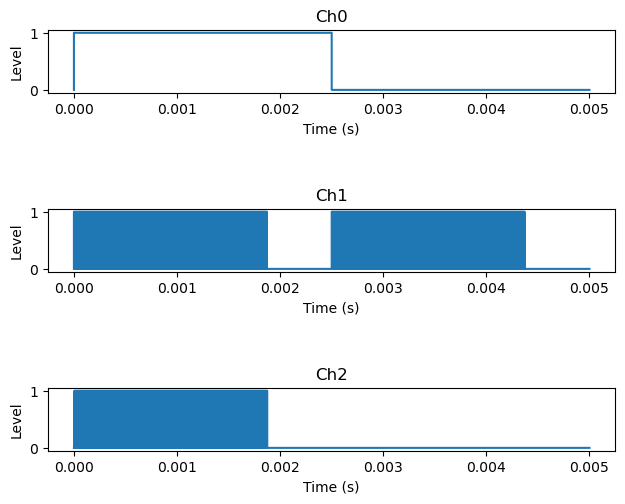

In [4]:
# Pulse sequence follows Sewani et al. 2020, Fig. 4(a) structure,
# but uses the timing values from the lab template.

pulse_blaster.reset_channel_buffer()

# CH0: 200 Hz square wave -> SR830 REF IN.
ch0_seq = [
    pulse(level=1, duration=tau_ref),   # HIGH: MW-on half-cycle
    pulse(level=0, duration=tau_ref),   # LOW:  MW-off half-cycle
]

# CH1: Laser fires in BOTH half-cycles (identical pattern -> background cancels in lock-in).
# Each unit: laser ON for tau_laser, then OFF for the MW slot.
laser_unit = [
    pulse(level=1, duration=tau_laser),
    pulse(level=0, duration=tau_padding + tau_mw + tau_padding),
]
laser_half = laser_unit * N + [pulse(level=0, duration=T_gap)]
ch1_seq = laser_half + laser_half

# CH2: MW gate fires ONLY in the first (HIGH) half-cycle.
# After the laser fires each unit, CH2 goes HIGH for tau_mw, then LOW.
mw_unit_on = [
    pulse(level=0, duration=tau_laser + tau_padding),   # wait for laser
    pulse(level=1, duration=tau_mw),                    # MW ON
    pulse(level=0, duration=tau_padding),               # trailing guard
]
mw_unit_off = [
    pulse(level=0, duration=T_unit),   # MW silent for entire unit
]

ch2_half_on  = mw_unit_on  * N + [pulse(level=0, duration=T_gap)]
ch2_half_off = mw_unit_off * N + [pulse(level=0, duration=T_gap)]
ch2_seq = ch2_half_on + ch2_half_off

pulse_blaster.ch0.pulse_sequence_buffer.set(ch0_seq)
pulse_blaster.ch1.pulse_sequence_buffer.set(ch1_seq)
pulse_blaster.ch2.pulse_sequence_buffer.set(ch2_seq)

pulse_blaster.plot_channel_buffer()   # inspect timing diagram before running

#### SR830 config

In [ ]:
lock_in_amp.reference_source.set('external')   # lock to CH0 square wave at REF IN
lock_in_amp.input_config('a')           # single-ended voltage input A

# Time constant: 30 ms to match the template's lockin_settle_time = 0.2 s.
# At 30 ms: 200 ms / 30 ms = 6.7 time constants -> > 99% settled. (SR830m.pdf, p. 3-14)
# At 100 ms: 200 ms / 100 ms = 2 time constants -> only ~86% settled -> noisy readings.
tau_c = 30e-3
lock_in_amp.time_constant(tau_c)

# Sensitivity: start at 500 uV. Adjust if OVLD lights up (increase) or signal
# is below 10% of full-scale (decrease). Valid range: 2 nV to 1 V (SR830m.pdf, p. 6-3).
lock_in_amp.sensitivity(500e-6)

# ENBW = 1/(4 * tau_c) = 1/(4 * 0.03) = 8.33 Hz
# Noise floor = 6 nV/sqrt(Hz) * sqrt(8.33) ~ 17 nVrms
# This is wider bandwidth (more noise) than 100 ms, but settle time is only 200 ms -> faster sweep.
t_settle = 0.2   # [s]  from template: lockin_settle_time = 0.2

print(f"Time constant : {tau_c*1e3:.0f} ms")
print(f"ENBW          : {1/(4*tau_c):.2f} Hz")
print(f"Noise floor   : {6e-9 * (1/(4*tau_c))**0.5 * 1e9:.1f} nVrms")
print(f"Settle time   : {t_settle*1e3:.0f} ms  ({t_settle/tau_c:.1f} time constants)")

Time constant : 30 ms
ENBW          : 8.33 Hz
Noise floor   : 17.3 nVrms
Settle time   : 200 ms  (6.7 time constants)


#### qcodes exp

In [6]:
MW_freq = qc.ManualParameter('mw_frequency', unit='Hz')
LI_R    = qc.ManualParameter('signal',       unit='V')

initialise_or_create_database_at(Path.cwd() / 'ODMR_Lab.db')

experiment = load_or_create_experiment(
    experiment_name='ODMR_Spectrum',
    sample_name='NV_diamond',
)

meas = Measurement(exp=experiment, name='zero_field_ODMR')
meas.register_parameter(MW_freq)
meas.register_parameter(LI_R, setpoints=(MW_freq,))

#### frequency sweep params

In [7]:
# From template: freq_min=2.77, freq_max=2.97, num_freqs=128 (in GHz).
# Wider range than I previously wrote (2.80-2.94): this ensures you capture
# the outer hyperfine satellites at D +/- 128 MHz (Sewani et al. 2020, Fig. 4b).
f_start   = 2.77e9   # [Hz]
f_stop    = 2.97e9   # [Hz]
n_pts     = 128

freq_list = np.linspace(f_start, f_stop, n_pts)
step_MHz  = (f_stop - f_start) / (n_pts - 1) / 1e6
total_s   = n_pts * t_settle

print(f"Sweep  : {f_start/1e9:.2f} to {f_stop/1e9:.2f} GHz")
print(f"Step   : {step_MHz:.2f} MHz  ({n_pts} points)")
print(f"Dwell  : {t_settle*1e3:.0f} ms per point")
print(f"Total  : ~{total_s:.0f} s  (~{total_s/60:.1f} min)")

Sweep  : 2.77 to 2.97 GHz
Step   : 1.57 MHz  (128 points)
Dwell  : 200 ms per point
Total  : ~26 s  (~0.4 min)


#### run sweep

In [8]:
pulse_blaster.flush_channel_buffer()   # compile and start the PulseBlaster loop
sleep(t_settle)                        # let SR830 reach steady state on reference

microwave_src.output('ON')             # only after antenna is confirmed connected

with meas.run() as datasaver:
    for f_mw in freq_list:
        microwave_src.frequency(f_mw)
        sleep(t_settle)
        r_val = lock_in_amp.R()
        datasaver.add_result((MW_freq, f_mw), (LI_R, r_val))
        print(f"  {f_mw/1e9:.4f} GHz   R = {r_val*1e6:.2f} uV")

microwave_src.output('OFF')
pulse_blaster.stop()

odmr_dataset = datasaver.dataset
print(f"\nDone. Run ID: {odmr_dataset.run_id}")

Starting experimental run with id: 5. 
  2.7700 GHz   R = 1.16 uV
  2.7716 GHz   R = 0.30 uV
  2.7731 GHz   R = 0.75 uV
  2.7747 GHz   R = 0.66 uV
  2.7763 GHz   R = 0.27 uV
  2.7779 GHz   R = 1.01 uV
  2.7794 GHz   R = 0.39 uV
  2.7810 GHz   R = 0.30 uV
  2.7826 GHz   R = 0.45 uV
  2.7842 GHz   R = 0.33 uV
  2.7857 GHz   R = 0.30 uV
  2.7873 GHz   R = 0.63 uV
  2.7889 GHz   R = 0.45 uV
  2.7905 GHz   R = 0.24 uV
  2.7920 GHz   R = 2.21 uV
  2.7936 GHz   R = 0.60 uV
  2.7952 GHz   R = 0.42 uV
  2.7968 GHz   R = 0.06 uV
  2.7983 GHz   R = 0.45 uV
  2.7999 GHz   R = 0.95 uV
  2.8015 GHz   R = 0.60 uV
  2.8031 GHz   R = 0.36 uV
  2.8046 GHz   R = 0.30 uV
  2.8062 GHz   R = 0.57 uV
  2.8078 GHz   R = 0.33 uV
  2.8094 GHz   R = 0.75 uV
  2.8109 GHz   R = 0.86 uV
  2.8125 GHz   R = 1.01 uV
  2.8141 GHz   R = 0.48 uV
  2.8157 GHz   R = 0.95 uV
  2.8172 GHz   R = 0.42 uV
  2.8188 GHz   R = 1.01 uV
  2.8204 GHz   R = 1.16 uV
  2.8220 GHz   R = 1.16 uV
  2.8235 GHz   R = 1.13 uV
  2.8251 GHz   R

#### data analysis

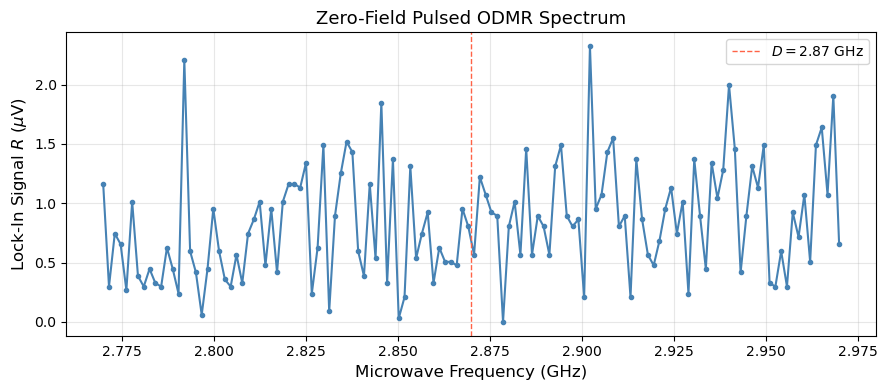

In [9]:
df = odmr_dataset.to_pandas_dataframe().reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    df['mw_frequency'] / 1e9,
    df['signal'] * 1e6,
    color='steelblue', lw=1.5, marker='o', ms=3,
)
ax.axvline(2.87, color='tomato', ls='--', lw=1, label=r'$D = 2.87\ \mathrm{GHz}$')
ax.set_xlabel('Microwave Frequency (GHz)', fontsize=12)
ax.set_ylabel(r'Lock-In Signal $R$ ($\mu$V)', fontsize=12)
ax.set_title('Zero-Field Pulsed ODMR Spectrum', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

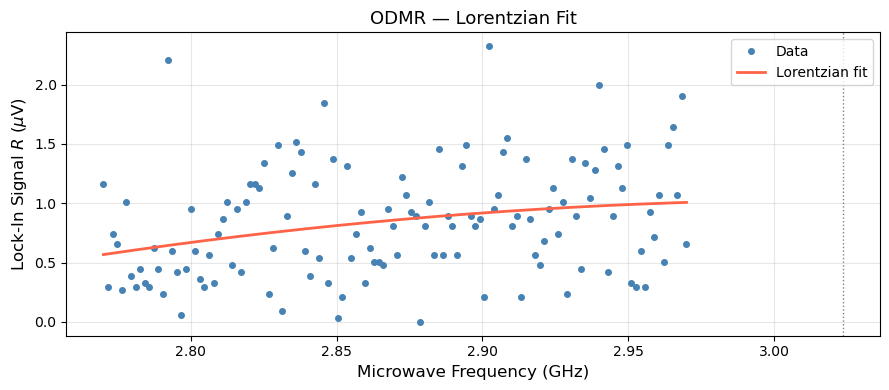

Peak center : 3.02369 +/- 804.027 MHz GHz
FWHM        : -17950.86 +/- 38280853.86 MHz
Amplitude   : 576.69 uV


In [10]:
from scipy.optimize import curve_fit

def lorentzian(f, f0, gamma, A, C):
    return A / (1.0 + ((f - f0) / gamma)**2) + C

f_arr = df['mw_frequency'].values
r_arr = df['signal'].values

p0   = [2.87e9, 5e6, r_arr.max() - r_arr.min(), r_arr.min()]
popt, pcov = curve_fit(lorentzian, f_arr, r_arr, p0=p0, maxfev=5000)
f0_fit, gamma_fit, A_fit, C_fit = popt
perr = np.sqrt(np.diag(pcov))

f_fine = np.linspace(f_arr.min(), f_arr.max(), 2000)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(f_arr / 1e9, r_arr * 1e6, 'o', ms=4, color='steelblue', label='Data')
ax.plot(f_fine / 1e9, lorentzian(f_fine, *popt) * 1e6,
        color='tomato', lw=2, label='Lorentzian fit')
ax.axvline(f0_fit / 1e9, color='gray', ls=':', lw=1)
ax.set_xlabel('Microwave Frequency (GHz)', fontsize=12)
ax.set_ylabel(r'Lock-In Signal $R$ ($\mu$V)', fontsize=12)
ax.set_title('ODMR — Lorentzian Fit', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak center : {f0_fit/1e9:.5f} +/- {perr[0]/1e6:.3f} MHz GHz")
print(f"FWHM        : {2*gamma_fit/1e6:.2f} +/- {2*perr[1]/1e6:.2f} MHz")
print(f"Amplitude   : {A_fit*1e6:.2f} uV")

### iter 2 (4/13/26)

#### instruments

In [2]:
# Reset the kernel in any other open notebook before running this cell.
pulse_blaster = spincore.PulseBlasterESRPRO(name='pulse_blaster', board_number=0)
pulse_blaster.core_clock(500)   # 500 MHz clock -> 2 ns resolution

lock_in_amp = stanford_research.SR830(
    name='lock_in_amp',
    address='ASRL5::INSTR',
    terminator='\r',
)

microwave_src = anritsu.MG3681A(
    name='microwave_src',
    address='ASRL4::INSTR',
    terminator='\r\n',
)

# Template: sg.write('OLVL {mwpower} DBM') then sg.write('LVL ON') before the loop.
# LVL ON is deferred to the sweep cell (antenna must be connected first).
microwave_src.output_level_unit('dBm')
microwave_src.IQ_modulation('EXT')   # CH2 gates MW via Anritsu I-input
microwave_src.power(-6)              # template: mwpower = -6
microwave_src.output('OFF')

pulse_blaster.stop()

2026-04-13 16:10:15,579 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ c:\Users\nv-group02\anaconda3\envs\mqst\Lib\site-packages\qcodes\instrument\instrument_base.py:188: QCoDeSDeprecationWarning: Parameter ch1_databuffer on instrument lock_in_amp does not correctly pass kwargs to its baseclass. A Parameter class must take `**kwargs` and forward them to its baseclass.
  warnings.warn(

2026-04-13 16:10:15,633 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ c:\Users\nv-group02\anaconda3\envs\mqst\Lib\site-packages\qcodes\instrument\instrument_base.py:188: QCoDeSDeprecationWarning: Parameter ch2_databuffer on instrument lock_in_amp does not correctly pass kwargs to its baseclass. A Parameter class must take `**kwargs` and forward them to its baseclass.
  warnings.warn(



Connected to: Stanford_Research_Systems SR830 (serial:s/n32132, firmware:ver1.07) in 0.29s
Connected to: ANRITSU MG3681A (serial:6100146424, firmware:3.03) in 0.13s


0

#### timing params

In [ ]:
# All times in nanoseconds — matches the template's spinapi unit convention
# (template: ms=1000000, us=1000, so Tref=2.5*ms=2500000, Tlaser=4*us=4000, etc.)

Tref     = 2_500_000   # ns  (2.5 ms half-period -> 200 Hz reference)
Tlaser   = 4_000       # ns  (4 µs)   template: Tlaser = 4*us
Tmw      = 3_000       # ns  (3 µs)   template: Tmw = 3*us
Tpadding = 250         # ns  (0.25 µs) template: Tpadding = 0.25*us
Nrepeat  = 250         # template: Nrepeat = 250

Tunit = Tref // Nrepeat                    # 10000 ns per laser+MW unit
Twait = Tunit - Tlaser - Tmw - Tpadding   # 2750 ns between laser and MW

assert Twait > 0, "Treference is too short for requested Nrepeat"

# Channel bitmasks — template uses 8-bit patterns with bits 4-7 mirroring 0-3
# for oscilloscope monitoring.  The QCodes driver uses 4 channels (bits 0-3).
# FLAG_MASK (bits 21-23) is ORed in automatically by send_instruction.
reference = 0b00010001   # CH0 -> SR830 REF IN
laser     = 0b00100010   # CH1 -> AOM / laser gate
mw_i      = 0b01000100   # CH2 -> Anritsu I-input (MW gate)
zeros     = 0b00000000

print(f"Tunit  = {Tunit} ns  ({Tunit/1e3:.1f} µs)")
print(f"Twait  = {Twait} ns  ({Twait/1e3:.2f} µs)")
print(f"T_HIGH = {Tref} ns  ({Tref/1e6:.1f} ms) [verified]")
print(f"T_LOW  = {Tref} ns  ({Tref/1e6:.1f} ms) [verified]")

Tunit  = 10000 ns  (10.0 µs)
Twait  = 2750 ns  (2.75 µs)
T_HIGH = 2500000 ns  (2.5 ms) [verified]
T_LOW  = 2500000 ns  (2.5 ms) [verified]


#### pulse sequence

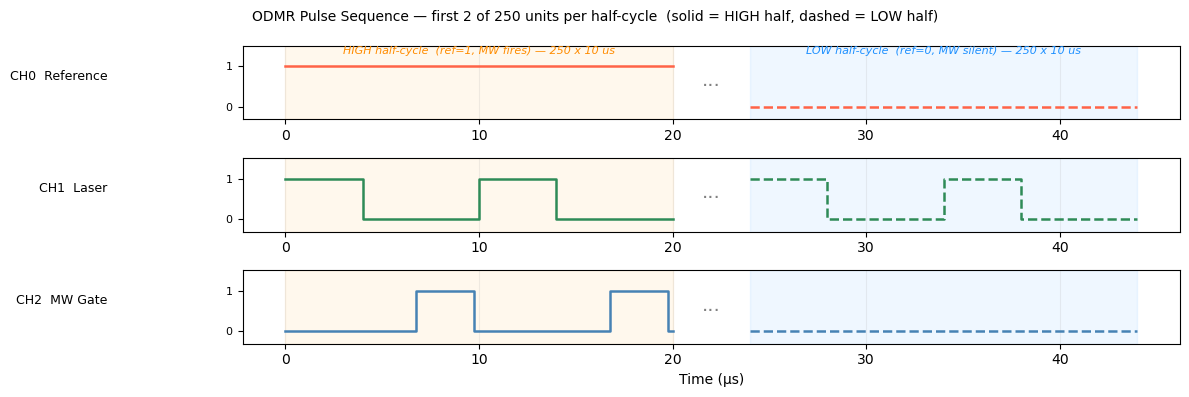

In [ ]:
# The pulse sequence is the same for every MW frequency, so we program once
# here rather than inside the sweep loop (unlike the template which reprograms
# each iteration — the sequence itself never changes between iterations).
#
# Sequence structure mirrors the template exactly:
#
#  HIGH half (reference=1, MW fires):
#    [laser+ref] -> [wait+ref] -> [mw+ref]          <- first unit (no padding before)
#    LOOP x(Nrepeat-1):
#      [padding+ref] -> [laser+ref] -> [wait+ref] -> [mw+ref END_LOOP]
#    [padding+ref]                                   <- close out final unit
#
#  LOW half (reference=0, MW silent):
#    [laser] -> LOOP x(Nrepeat-1): [zeros] -> [laser END_LOOP] -> [zeros BRANCH->start]

pulse_blaster.start_programming()

# ── HIGH half-cycle ───────────────────────────────────────────────────────────
start = pulse_blaster.send_instruction(
    reference | laser, 'CONTINUE', 0, Tlaser)       # laser ON, ref HIGH

pulse_blaster.send_instruction(
    reference, 'CONTINUE', 0, Twait)                # wait (laser OFF, mw OFF)

pulse_blaster.send_instruction(
    reference | mw_i, 'CONTINUE', 0, Tmw)           # MW ON, ref HIGH

loop_high = pulse_blaster.send_instruction(
    reference, 'LOOP', Nrepeat - 1, Tpadding)       # padding; loop Nrepeat-1 more times

pulse_blaster.send_instruction(
    reference | laser, 'CONTINUE', 0, Tlaser)       # laser ON

pulse_blaster.send_instruction(
    reference, 'CONTINUE', 0, Twait)                # wait

pulse_blaster.send_instruction(
    reference | mw_i, 'END_LOOP', loop_high, Tmw)   # MW ON, close loop

pulse_blaster.send_instruction(
    reference, 'CONTINUE', 0, Tpadding)             # final padding to complete last unit

# ── LOW half-cycle ────────────────────────────────────────────────────────────
pulse_blaster.send_instruction(
    laser, 'CONTINUE', 0, Tlaser)                   # laser ON, ref LOW, MW OFF

loop_low = pulse_blaster.send_instruction(
    zeros, 'LOOP', Nrepeat - 1, Tunit - Tlaser)     # zeros for remainder of unit; loop

pulse_blaster.send_instruction(
    laser, 'END_LOOP', loop_low, Tlaser)             # laser ON, close loop

pulse_blaster.send_instruction(
    zeros, 'BRANCH', start, Tunit - Tlaser)         # zeros, branch back to start

pulse_blaster.stop_programming()

def plot_sequence():
    def _segs_to_xy(segs):
        """Convert [(duration_ns, level), ...] to (x_us, y) arrays."""
        xs, ys, t = [], [], 0.0
        for dur, lvl in segs:
            xs += [t / 1e3, (t + dur) / 1e3]
            ys += [lvl, lvl]
            t  += dur
        return xs, ys

    def _high_segs(ch, n):
        """First n units of the HIGH half for channel ch."""
        # First unit has no leading padding (matches template: start = first instruction)
        segs = [(Tlaser, ch in (0, 1)), (Twait, ch == 0), (Tmw, ch in (0, 2))]
        for _ in range(n - 1):
            segs += [(Tpadding, ch == 0), (Tlaser, ch in (0, 1)),
                    (Twait,    ch == 0), (Tmw,    ch in (0, 2))]
        segs += [(Tpadding, ch == 0)]   # final padding closing the last unit
        return [(d, int(v)) for d, v in segs]

    def _low_segs(ch, n):
        """First n units of the LOW half for channel ch."""
        # Instruction before loop: laser once
        segs = [(Tlaser, ch == 1)]
        for _ in range(n - 1):
            segs += [(Tunit - Tlaser, 0), (Tlaser, ch == 1)]
        segs += [(Tunit - Tlaser, 0)]   # final zeros (BRANCH)
        return [(d, int(v)) for d, v in segs]

    N_show    = 2
    gap_us    = 4.0   # visual gap between HIGH and LOW panels (µs)
    ch_labels = ['CH0  Reference', 'CH1  Laser', 'CH2  MW Gate']
    colors    = ['tomato', 'seagreen', 'steelblue']

    fig, axes = plt.subplots(3, 1, figsize=(12, 4), sharex=False)

    for i, ax in enumerate(axes):
        xh, yh = _segs_to_xy(_high_segs(i, N_show))
        xl, yl = _segs_to_xy(_low_segs(i,  N_show))

        t_end_high = xh[-1]
        xl = [x + t_end_high + gap_us for x in xl]
        t_end_low  = xl[-1]
        mid_high   = t_end_high / 2
        mid_low    = (t_end_high + gap_us + t_end_low) / 2

        ax.plot(xh, yh, lw=1.8, color=colors[i])
        ax.plot(xl, yl, lw=1.8, color=colors[i], ls='--')
        ax.text(t_end_high + gap_us / 2, 0.5, '···',
                ha='center', va='center', fontsize=14, color='gray')

        ax.axvspan(0,                  t_end_high,  alpha=0.07, color='orange')
        ax.axvspan(t_end_high + gap_us, t_end_low,  alpha=0.07, color='dodgerblue')

        ax.set_ylim(-0.3, 1.5)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['0', '1'], fontsize=8)
        ax.set_ylabel(ch_labels[i], fontsize=9, rotation=0, ha='right', labelpad=85)
        ax.grid(True, alpha=0.2, axis='x')

        if i == 0:
            ax.text(mid_high, 1.3,
                    f'HIGH half-cycle  (ref=1, MW fires) — {Nrepeat} x {Tunit/1e3:.0f} us',
                    ha='center', fontsize=8, color='darkorange', style='italic')
            ax.text(mid_low, 1.3,
                    f'LOW half-cycle  (ref=0, MW silent) — {Nrepeat} x {Tunit/1e3:.0f} us',
                    ha='center', fontsize=8, color='dodgerblue', style='italic')

    axes[-1].set_xlabel('Time (µs)', fontsize=10)
    fig.suptitle(
        f'ODMR Pulse Sequence — first {N_show} of {Nrepeat} units per half-cycle  '
        f'(solid = HIGH half, dashed = LOW half)',
        fontsize=10)
    plt.tight_layout()
    plt.show()
plot_sequence()

#### SR830 config

In [36]:
# External reference from PulseBlaster CH0 wired to SR830 REF IN.
lock_in_amp.reference_source.set('external')
lock_in_amp.input_config('a') 
# lock_in_amp.input_config('I 1M')

# Template plot cells say: "lockin time constant = 30 ms"
# With lockin_settle_time = 0.2 s: 200 ms / 30 ms = 6.7 tau_c -> >99% settled.
tau_c = 30e-3
lock_in_amp.time_constant(tau_c)
lock_in_amp.sensitivity(500e-6)

lockin_settle_time = 0.2   # s — matches template exactly

print(f"Time constant : {tau_c*1e3:.0f} ms")
print(f"Settle time   : {lockin_settle_time*1e3:.0f} ms  ({lockin_settle_time/tau_c:.1f} tau_c)")

Time constant : 30 ms
Settle time   : 200 ms  (6.7 tau_c)


#### qcodes setup

In [37]:
MW_freq = qc.ManualParameter('mw_frequency', unit='Hz')
LI_R    = qc.ManualParameter('signal',       unit='V')

initialise_or_create_database_at(Path.cwd() / 'ODMR_Lab.db')

experiment = load_or_create_experiment(
    experiment_name='ODMR_Spectrum',
    sample_name='NV_diamond',
)

meas = Measurement(exp=experiment, name='zero_field_ODMR')
meas.register_parameter(MW_freq)
meas.register_parameter(LI_R, setpoints=(MW_freq,))

#### frequency sweep params

In [38]:
# Template: freq_min=2.77, freq_max=2.97, num_freqs=128 (GHz values)
# QCodes MG3681A parameter expects Hz, so convert here.
freq_min = 2.07e9   # Hz
freq_max = 2.67e9   # Hz
num_freqs = 128

freq_list = np.linspace(freq_min, freq_max, num_freqs)

print(f"Sweep : {freq_min/1e9:.2f} to {freq_max/1e9:.2f} GHz  ({num_freqs} pts)")
print(f"Step  : {(freq_max-freq_min)/(num_freqs-1)/1e6:.2f} MHz")
print(f"Total : ~{num_freqs * lockin_settle_time:.0f} s")

Sweep : 2.07 to 2.67 GHz  (128 pts)
Step  : 4.72 MHz
Total : ~26 s


#### run sweep

In [39]:
# Template: sg.write('LVL ON') before the loop, then pb_start() inside each
# iteration.  Here we start PB once and leave it running — the sequence loops
# continuously on hardware and the frequency is the only thing that changes.

pulse_blaster.start()
sleep(0.1)   # template: sleep(0.1) after pb_start to ensure program is running

microwave_src.output('ON')   # antenna must be connected before this line

with meas.run() as datasaver:
    for f_mw in tqdm_bar(freq_list, desc='ODMR sweep', unit='pt'):
        microwave_src.frequency(f_mw)
        sleep(lockin_settle_time)
        r_val = lock_in_amp.R()
        datasaver.add_result((MW_freq, f_mw), (LI_R, r_val))

microwave_src.output('OFF')
pulse_blaster.stop()

odmr_dataset = datasaver.dataset
print(f"Done. Run ID: {odmr_dataset.run_id}")

Starting experimental run with id: 18. 


ODMR sweep:   0%|          | 0/128 [00:00<?, ?pt/s]

Done. Run ID: 18


#### data analysis

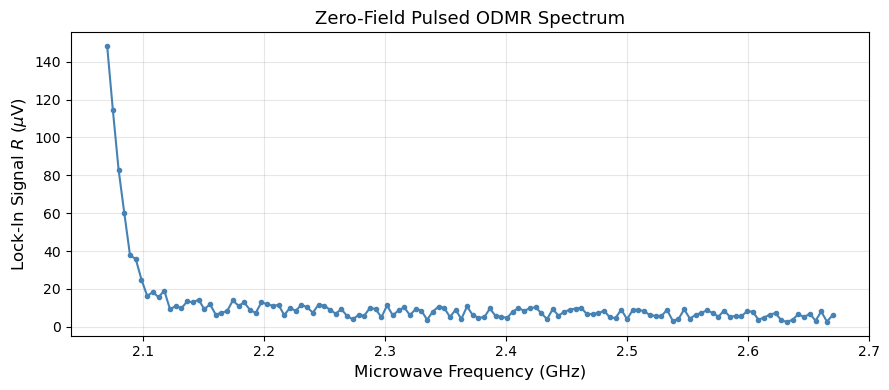

In [40]:
df = odmr_dataset.to_pandas_dataframe().reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    df['mw_frequency'] / 1e9,
    df['signal'] * 1e6,
    color='steelblue', lw=1.5, marker='o', ms=3,
)
# ax.axvline(2.87, color='tomato', ls='--', lw=1, label=r'$D = 2.87\ \mathrm{GHz}$')
ax.set_xlabel('Microwave Frequency (GHz)', fontsize=12)
ax.set_ylabel(r'Lock-In Signal $R$ ($\mu$V)', fontsize=12)
ax.set_title('Zero-Field Pulsed ODMR Spectrum', fontsize=13)
# ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

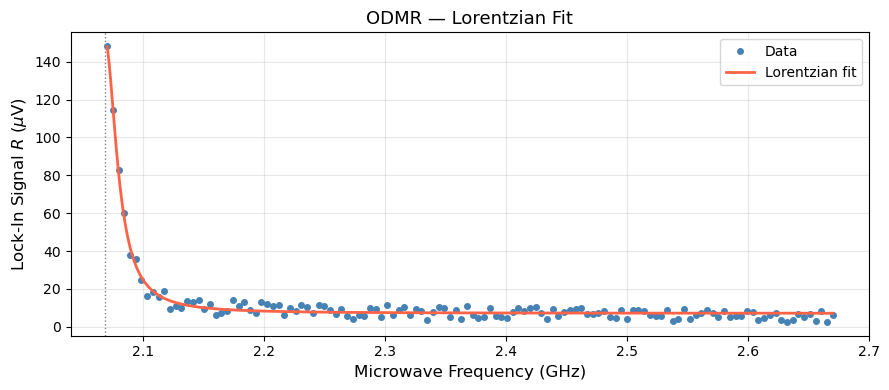

Peak center : 2.06783 +/- 0.769 MHz GHz
FWHM        : -23.69 +/- 0.88 MHz
Amplitude   : 145.60 uV


In [41]:
from scipy.optimize import curve_fit

def lorentzian(f, f0, gamma, A, C):
    return A / (1.0 + ((f - f0) / gamma)**2) + C

f_arr = df['mw_frequency'].values
r_arr = df['signal'].values

p0   = [2.87e9, 5e6, r_arr.max() - r_arr.min(), r_arr.min()]
popt, pcov = curve_fit(lorentzian, f_arr, r_arr, p0=p0, maxfev=5000)
f0_fit, gamma_fit, A_fit, C_fit = popt
perr = np.sqrt(np.diag(pcov))

f_fine = np.linspace(f_arr.min(), f_arr.max(), 2000)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(f_arr / 1e9, r_arr * 1e6, 'o', ms=4, color='steelblue', label='Data')
ax.plot(f_fine / 1e9, lorentzian(f_fine, *popt) * 1e6,
        color='tomato', lw=2, label='Lorentzian fit')
ax.axvline(f0_fit / 1e9, color='gray', ls=':', lw=1)
ax.set_xlabel('Microwave Frequency (GHz)', fontsize=12)
ax.set_ylabel(r'Lock-In Signal $R$ ($\mu$V)', fontsize=12)
ax.set_title('ODMR — Lorentzian Fit', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak center : {f0_fit/1e9:.5f} +/- {perr[0]/1e6:.3f} MHz GHz")
print(f"FWHM        : {2*gamma_fit/1e6:.2f} +/- {2*perr[1]/1e6:.2f} MHz")
print(f"Amplitude   : {A_fit*1e6:.2f} uV")

### iter 3 (4/15/26)

#### instruments

In [4]:
# Reset the kernel in any other open notebook before running this cell.
pulse_blaster = spincore.PulseBlasterESRPRO(name='pulse_blaster', board_number=0)
pulse_blaster.core_clock(500)   # 500 MHz clock -> 2 ns resolution

# lock_in_amp = stanford_research.SR830(
#     name='lock_in_amp',
#     address='ASRL5::INSTR',
#     terminator='\r',
# )

# microwave_src = anritsu.MG3681A(
#     name='microwave_src',
#     address='ASRL4::INSTR',
#     terminator='\r\n',
# )

# # Template: sg.write('OLVL {mwpower} DBM') then sg.write('LVL ON') before the loop.
# # LVL ON is deferred to the sweep cell (antenna must be connected first).
# microwave_src.output_level_unit('dBm')
# microwave_src.IQ_modulation('EXT')   # CH2 gates MW via Anritsu I-input
# microwave_src.power(-6)              # template: mwpower = -6
# microwave_src.output('OFF')

pulse_blaster.stop()

0

#### timing params

In [6]:
# All times in nanoseconds — matches the template's spinapi unit convention
# (template: ms=1000000, us=1000, so Tref=2.5*ms=2500000, Tlaser=4*us=4000, etc.)

Tref     = 5e6   # ns  (2.5 ms half-period -> 200 Hz reference)
Tlaser   = 4_000       # ns  (4 µs)   template: Tlaser = 4*us
Tmw      = 6_000       # ns  (3 µs)   template: Tmw = 3*us
Tpadding = 250         # ns  (0.25 µs) template: Tpadding = 0.25*us
Nrepeat  = 100         # template: Nrepeat = 250

Tunit = Tref // Nrepeat                    # 10000 ns per laser+MW unit
Twait = Tunit - Tlaser - Tmw - Tpadding   # 2750 ns between laser and MW

assert Twait > 0, "Treference is too short for requested Nrepeat"

# Channel bitmasks — template uses 8-bit patterns with bits 4-7 mirroring 0-3
# for oscilloscope monitoring.  The QCodes driver uses 4 channels (bits 0-3).
# FLAG_MASK (bits 21-23) is ORed in automatically by send_instruction.
REF     = 0b00010001   # CH0 -> SR830 REF IN
LASER   = 0b00100010   # CH1 -> AOM / laser gate
MW      = 0b01000100   # CH2 -> Anritsu I-input (MW gate)
OFF     = 0b00000000

print(f"Tunit  = {Tunit} ns  ({Tunit/1e3:.1f} µs)")
print(f"Twait  = {Twait} ns  ({Twait/1e3:.2f} µs)")
print(f"T_HIGH = {Tref} ns  ({Tref/1e6:.1f} ms) [verified]")
print(f"T_LOW  = {Tref} ns  ({Tref/1e6:.1f} ms) [verified]")

Tunit  = 50000.0 ns  (50.0 µs)
Twait  = 39750.0 ns  (39.75 µs)
T_HIGH = 5000000.0 ns  (5.0 ms) [verified]
T_LOW  = 5000000.0 ns  (5.0 ms) [verified]


#### pulse sequence

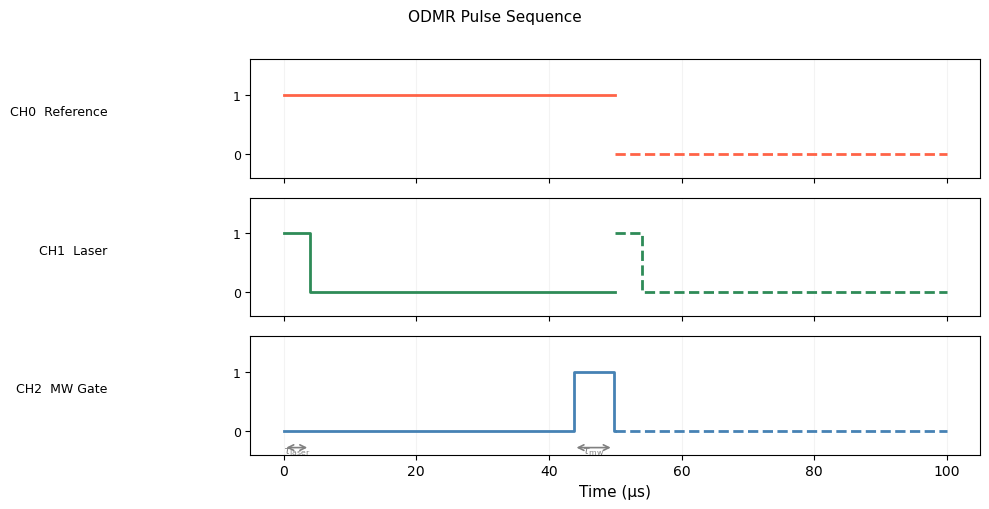

In [7]:
# The pulse sequence is the same for every MW frequency, so we program once
# here rather than inside the sweep loop (unlike the template which reprograms
# each iteration — the sequence itself never changes between iterations).
#
# Sequence structure mirrors the template exactly:
#
#  HIGH half (reference=1, MW fires):
#    [laser+ref] -> [wait+ref] -> [mw+ref]          <- first unit (no padding before)
#    LOOP x(Nrepeat-1):
#      [padding+ref] -> [laser+ref] -> [wait+ref] -> [mw+ref END_LOOP]
#    [padding+ref]                                   <- close out final unit
#
#  LOW half (reference=0, MW silent):
#    [laser] -> LOOP x(Nrepeat-1): [zeros] -> [laser END_LOOP] -> [zeros BRANCH->start]

pulse_blaster.start_programming()

# ════════════════════════════════════════════════════════════════════════════
# HIGH HALF-CYCLE  (CH0 = 1, reference HIGH, MW fires)
# ════════════════════════════════════════════════════════════════════════════

# ── First unit (unrolled — no leading Tpadding on the very first unit) ────
#    This is the "start" address the final BRANCH will return to.

# Step 1: Laser ON — initializes spin into |0>_g via optical pumping.
#         CH0=1 (ref HIGH), CH1=1 (laser), CH2=0 (MW off)
start = pulse_blaster.send_instruction(REF | LASER, 'CONTINUE', 0, Tlaser)

# Step 2: Pre-MW wait — laser OFF, MW not yet on.
#         Gives AOM time to fully close before MW fires (Twait >> AOM rise time).
#         CH0=1, CH1=0, CH2=0
pulse_blaster.send_instruction(REF, 'CONTINUE', 0, Twait)

# Step 3: MW ON — drives |0>_g -> |±1>_g if frequency is resonant.
#         CH0=1, CH1=0, CH2=1
pulse_blaster.send_instruction(REF | MW, 'CONTINUE', 0, Tmw)

# ── Units 2 through N (loop body, executes Nrepeat-1 times) ──────────────

# Step 4: Post-MW guard — inter-unit dead time; also the LOOP instruction.
#         The LOOP address is what END_LOOP branches back to.
#         inst_args = Nrepeat-1 -> loop executes Nrepeat-1 more times,
#         giving Nrepeat total executions of [laser, Twait, MW].
#         CH0=1, CH1=0, CH2=0
loop_high = pulse_blaster.send_instruction(REF, 'LOOP', Nrepeat - 1, Tpadding)

# Step 5 (loop body): Laser ON again — readout of previous spin state AND
#         initialization for next unit. Same duration as step 1.
pulse_blaster.send_instruction(REF | LASER, 'CONTINUE', 0, Tlaser)

# Step 6 (loop body): Pre-MW wait — same as step 2.
pulse_blaster.send_instruction(REF, 'CONTINUE', 0, Twait)

# Step 7 (loop body): MW ON, END_LOOP — jumps back to step 4 (loop_high)
#         until Nrepeat-1 iterations are complete.
pulse_blaster.send_instruction(REF | MW, 'END_LOOP', loop_high, Tmw)

# Step 8: Final post-MW guard — closes the last unit of the HIGH half-cycle.
#         Without this, the HIGH half would be 250 ns short of Tref.
pulse_blaster.send_instruction(REF, 'CONTINUE', 0, Tpadding)

# ════════════════════════════════════════════════════════════════════════════
# LOW HALF-CYCLE  (CH0 = 0, reference LOW, MW silent)
# ════════════════════════════════════════════════════════════════════════════
#
# Laser fires N times — same positions as in HIGH half — but CH2 stays LOW.
# The lock-in sees (HIGH PL) - (LOW PL) = MW-induced PL change only.

# Step 9: First laser pulse of LOW half — identical length to step 1.
#         CH0=0, CH1=1, CH2=0
pulse_blaster.send_instruction(LASER, 'CONTINUE', 0, Tlaser)

# Step 10: LOOP for Nrepeat-1 more units — fills the rest of the unit with zeros.
#          (Tunit - Tlaser) = 6000 ns idle after each laser pulse.
#          CH0=0, CH1=0, CH2=0
loop_low = pulse_blaster.send_instruction(OFF, 'LOOP', Nrepeat - 1, Tunit - Tlaser)

# Step 11 (loop body): Laser ON — same position as HIGH half laser pulses.
pulse_blaster.send_instruction(LASER, 'END_LOOP', loop_low, Tlaser)

# Step 12: Final idle + BRANCH back to start (step 1).
#          Completes the last unit of the LOW half, then restarts the full
#          2*Tref = 5 ms sequence continuously until pb_stop() is called.
#          CH0=0, CH1=0, CH2=0
pulse_blaster.send_instruction(OFF, 'BRANCH', start, Tunit - Tlaser)

pulse_blaster.stop_programming()

def plot_sequence():
    N_show = 1

    def build_waveform(segs):
        t, xs, ys = 0.0, [], []
        for dur, lvl in segs:
            xs += [t / 1e3, (t + dur) / 1e3]
            ys += [lvl, lvl]
            t  += dur
        return xs, ys

    def unit_high(ch):
        return [
            (Tlaser,   ch in (0, 1)),
            (Twait,    ch == 0),
            (Tmw,      ch in (0, 2)),
            (Tpadding, ch == 0),
        ]

    def unit_low(ch):
        return [
            (Tlaser,         ch == 1),
            (Tunit - Tlaser, False),
        ]

    ch_labels = ['CH0  Reference', 'CH1  Laser', 'CH2  MW Gate']
    colors     = ['tomato', 'seagreen', 'steelblue']

    fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
    fig.subplots_adjust(hspace=0.08)

    for ch, ax in enumerate(axes):
        high_segs = [(d, int(v)) for d, v in unit_high(ch)]
        low_segs  = [(d, int(v)) for d, v in unit_low(ch)]

        xh, yh = build_waveform(high_segs)
        xl, yl = build_waveform(low_segs)

        t_low_off = xh[-1]
        xl = [x + t_low_off for x in xl]

        ax.plot(xh, yh, lw=2.0, color=colors[ch], drawstyle='steps-post')
        ax.plot(xl, yl, lw=2.0, color=colors[ch], drawstyle='steps-post', ls='--')

        ax.set_ylim(-0.4, 1.6)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['0', '1'], fontsize=9)
        ax.set_ylabel(ch_labels[ch], fontsize=9, rotation=0, ha='right', labelpad=90)
        ax.grid(True, alpha=0.15, axis='x')

        if ch == 2:
            ax.annotate('', xy=(Tlaser/1e3, -0.28), xytext=(0, -0.28),
                        arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
            ax.text(Tlaser/2e3, -0.38, r'$\tau_\mathrm{laser}$',
                    ha='center', fontsize=8, color='gray')

            t1 = (Tlaser + Twait) / 1e3
            ax.annotate('', xy=(t1 + Tmw/1e3, -0.28), xytext=(t1, -0.28),
                        arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
            ax.text(t1 + Tmw/2e3, -0.38, r'$\tau_\mathrm{mw}$',
                    ha='center', fontsize=8, color='gray')

    axes[-1].set_xlabel('Time (µs)', fontsize=11)
    fig.suptitle('ODMR Pulse Sequence', fontsize=11, y=1.01)

    plt.tight_layout()
    plt.show()
plot_sequence()

In [8]:
pulse_blaster.start()

0

#### SR830 config

In [5]:
# External reference from PulseBlaster CH0 wired to SR830 REF IN.
lock_in_amp.reference_source.set('external')
lock_in_amp.input_config('a') 
# lock_in_amp.input_config('I 1M')

# Template plot cells say: "lockin time constant = 30 ms"
# With lockin_settle_time = 0.2 s: 200 ms / 30 ms = 6.7 tau_c -> >99% settled.
tau_c = 30e-3
lock_in_amp.time_constant(tau_c)
lock_in_amp.sensitivity(500e-6)

lockin_settle_time = 0.2   # s — matches template exactly

print(f"Time constant : {tau_c*1e3:.0f} ms")
print(f"Settle time   : {lockin_settle_time*1e3:.0f} ms  ({lockin_settle_time/tau_c:.1f} tau_c)")

Time constant : 30 ms
Settle time   : 200 ms  (6.7 tau_c)


#### qcodes setup

In [6]:
MW_freq = qc.ManualParameter('mw_frequency', unit='Hz')
LI_R    = qc.ManualParameter('signal',       unit='V')

initialise_or_create_database_at(Path.cwd() / 'ODMR_Lab.db')

experiment = load_or_create_experiment(
    experiment_name='ODMR_Spectrum',
    sample_name='NV_diamond',
)

meas = Measurement(exp=experiment, name='zero_field_ODMR')
meas.register_parameter(MW_freq)
meas.register_parameter(LI_R, setpoints=(MW_freq,))

#### frequency sweep params

In [7]:
# Template: freq_min=2.77, freq_max=2.97, num_freqs=128 (GHz values)
# QCodes MG3681A parameter expects Hz, so convert here.
ms_steps = 5 * tau_c
step_spacing_Hz = ms_steps * 1000
num_freqs = 1000

freq_min = 2.80e9   # Hz
freq_max = 2.90e9   # Hz


freq_list = np.linspace(freq_min, freq_max, num_freqs)

print(f"Sweep : {freq_min/1e9:.2f} to {freq_max/1e9:.2f} GHz  ({num_freqs} pts)")
print(f"Step  : {(freq_max-freq_min)/(num_freqs-1)/1e6:.2f} MHz")
print(f"Total : ~{num_freqs * lockin_settle_time:.0f} s")

Sweep : 2.80 to 2.90 GHz  (1000 pts)
Step  : 0.10 MHz
Total : ~200 s


#### run sweep

In [8]:
# Template: sg.write('LVL ON') before the loop, then pb_start() inside each
# iteration.  Here we start PB once and leave it running — the sequence loops
# continuously on hardware and the frequency is the only thing that changes.

pulse_blaster.start()
sleep(0.1)   # template: sleep(0.1) after pb_start to ensure program is running

microwave_src.output('ON')   # antenna must be connected before this line

with meas.run() as datasaver:
    for f_mw in tqdm_bar(freq_list, desc='ODMR sweep', unit='pt'):
        microwave_src.frequency(f_mw)
        sleep(lockin_settle_time)
        r_val = lock_in_amp.R()
        datasaver.add_result((MW_freq, f_mw), (LI_R, r_val))

microwave_src.output('OFF')
pulse_blaster.stop()

odmr_dataset = datasaver.dataset
print(f"Done. Run ID: {odmr_dataset.run_id}")

Starting experimental run with id: 26. 


ODMR sweep:   0%|          | 0/1000 [00:00<?, ?pt/s]

Done. Run ID: 26


#### data analysis

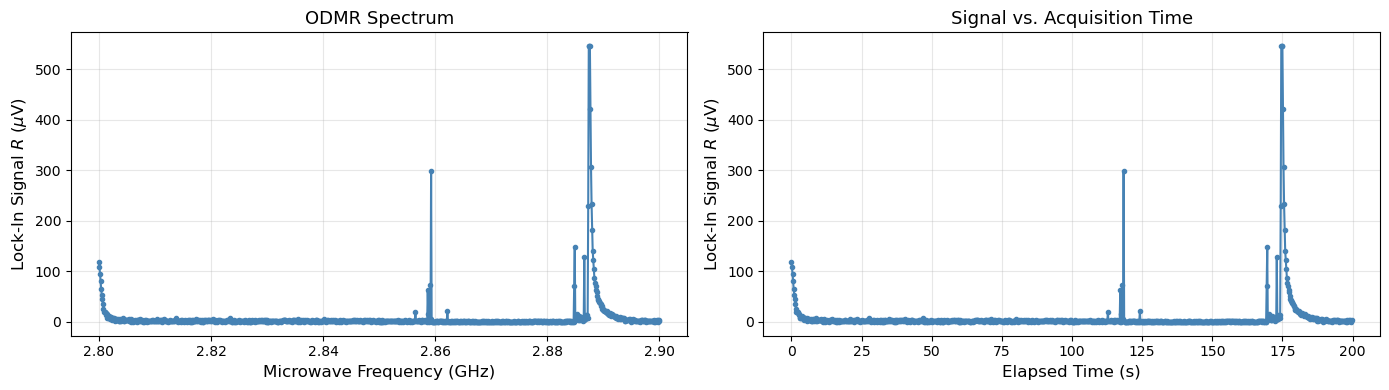

In [9]:
df = odmr_dataset.to_pandas_dataframe().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Frequency domain ──────────────────────────────────────────────────────────
axes[0].plot(
    df['mw_frequency'] / 1e9,
    df['signal'] * 1e6,
    color='steelblue', lw=1.5, marker='o', ms=3,
)
axes[0].set_xlabel('Microwave Frequency (GHz)', fontsize=12)
axes[0].set_ylabel(r'Lock-In Signal $R$ ($\mu$V)', fontsize=12)
axes[0].set_title('ODMR Spectrum', fontsize=13)
axes[0].grid(True, alpha=0.3)

# ── Time domain ───────────────────────────────────────────────────────────────
t_axis = np.arange(len(df)) * lockin_settle_time

axes[1].plot(
    t_axis,
    df['signal'] * 1e6,
    color='steelblue', lw=1.5, marker='o', ms=3,
)
axes[1].set_xlabel('Elapsed Time (s)', fontsize=12)
axes[1].set_ylabel(r'Lock-In Signal $R$ ($\mu$V)', fontsize=12)
axes[1].set_title('Signal vs. Acquisition Time', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

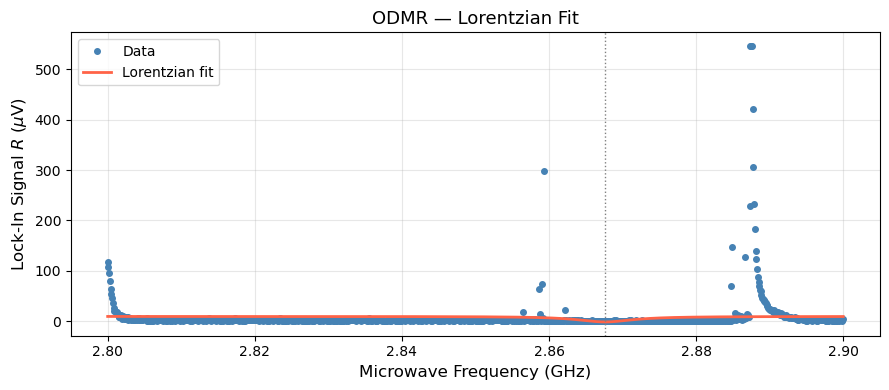

Peak center : 2.86763 +/- 2.743 MHz GHz
FWHM        : 9.18 +/- 8.99 MHz
Amplitude   : -10.94 uV


In [10]:
def lorentzian(f, f0, gamma, A, C):
    return A / (1.0 + ((f - f0) / gamma)**2) + C

f_arr = df['mw_frequency'].values
r_arr = df['signal'].values

p0   = [2.87e9, 5e6, r_arr.max() - r_arr.min(), r_arr.min()]
popt, pcov = curve_fit(lorentzian, f_arr, r_arr, p0=p0, maxfev=5000)
f0_fit, gamma_fit, A_fit, C_fit = popt
perr = np.sqrt(np.diag(pcov))

f_fine = np.linspace(f_arr.min(), f_arr.max(), 2000)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(f_arr / 1e9, r_arr * 1e6, 'o', ms=4, color='steelblue', label='Data')
ax.plot(f_fine / 1e9, lorentzian(f_fine, *popt) * 1e6,
        color='tomato', lw=2, label='Lorentzian fit')
ax.axvline(f0_fit / 1e9, color='gray', ls=':', lw=1)
ax.set_xlabel('Microwave Frequency (GHz)', fontsize=12)
ax.set_ylabel(r'Lock-In Signal $R$ ($\mu$V)', fontsize=12)
ax.set_title('ODMR — Lorentzian Fit', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak center : {f0_fit/1e9:.5f} +/- {perr[0]/1e6:.3f} MHz GHz")
print(f"FWHM        : {2*gamma_fit/1e6:.2f} +/- {2*perr[1]/1e6:.2f} MHz")
print(f"Amplitude   : {A_fit*1e6:.2f} uV")

### iter 4

#### instruments

In [5]:
class RigolDS1104:
    def __init__(self, resource):
        self.rm = pyvisa.ResourceManager()
        self.inst = self.rm.open_resource(resource)
        self.inst.timeout = 5000

    def idn(self):
        return self.inst.query("*IDN?")

    def get_waveform(self, channel=1):
        # Set source channel
        self.inst.write(f":WAV:SOUR CHAN{channel}")
        self.inst.write(":WAV:MODE NORM")
        self.inst.write(":WAV:FORM BYTE")

        # Query preamble (scaling info)
        preamble = self.inst.query(":WAV:PRE?").split(',')
        x_increment = float(preamble[4])
        x_origin = float(preamble[5])
        y_increment = float(preamble[7])
        y_origin = float(preamble[8])
        y_ref = float(preamble[9])

        # Get raw data
        raw = self.inst.query_binary_values(":WAV:DATA?", datatype='B', container=np.array)

        # Convert to voltage
        voltages = (raw - y_ref) * y_increment + y_origin
        times = np.arange(len(raw)) * x_increment + x_origin

        return times, voltages

    def close(self):
        self.inst.close()



In [6]:
for name in ['lock_in_amp', 'microwave_src', 'pulse_blaster']:
    if name in qc.instrument.instrument.Instrument._all_instruments:
        qc.instrument.instrument.Instrument._all_instruments[name].close()

pyvisa_rm = pyvisa.ResourceManager()
for resource in pyvisa_rm.list_resources(): print(resource)

pulse_blaster = spincore.PulseBlasterESRPRO(name='pulse_blaster', board_number=0)
pulse_blaster.core_clock(500)

_resource = pyvisa_rm.open_resource('ASRL5::INSTR')
_resource.baud_rate = 9600
_resource.data_bits = 8
_resource.write('OUTX 0\r')

lock_in_amp = stanford_research.SR830(
    name='lock_in_amp',
    address=None,
    terminator='\r',
    resource=_resource,
)

mwpower = -6
microwave_src = anritsu.MG3681A(
    name='microwave_src',
    address='ASRL4::INSTR',
    terminator='\r\n',
)
microwave_src.output_level_unit('dBm')
microwave_src.IQ_modulation('EXT')
microwave_src.power(mwpower)
microwave_src.output('OFF')

scope = RigolDS1104('USB0::0x1AB1::0x04CE::DS1ZC232502790::INSTR')
pulse_blaster.stop()


USB0::0x1AB1::0x04CE::DS1ZC232502790::INSTR
ASRL1::INSTR
ASRL3::INSTR
ASRL4::INSTR
ASRL5::INSTR
ASRL6::INSTR
Connected to: Stanford_Research_Systems SR830 (serial:s/n32132, firmware:ver1.07) in 0.19s
Connected to: ANRITSU MG3681A (serial:6100146424, firmware:3.03) in 0.14s


0

#### timing params

In [ ]:
# All times in nanoseconds — matches the template's spinapi unit convention
# (template: ms=1000000, us=1000, so Tref=2.5*ms=2500000, Tlaser=4*us=4000, etc.)

Tref     = 1000 * 16000   # ns  (2.5 ms half-period -> 200 Hz reference)
Tlaser   = 5_000       # ns  (4 µs)   template: Tlaser = 4*us
Tmw      = 10_000       # ns  (3 µs)   template: Tmw = 3*us
Tpadding = 1000         # ns  (0.25 µs) template: Tpadding = 0.25*us
Nrepeat  = 1000        

Tunit = Tref // Nrepeat                    # 10000 ns per laser+MW unit
Twait = 1000 #Tunit - Tlaser - Tmw - Tpadding   # 2750 ns between laser and MW

assert Twait > 0, "Treference is too short for requested Nrepeat"

# Channel bitmasks — template uses 8-bit patterns with bits 4-7 mirroring 0-3
# for oscilloscope monitoring.  The QCodes driver uses 4 channels (bits 0-3).
# FLAG_MASK (bits 21-23) is ORed in automatically by send_instruction.
REF     = 0b00010001   # CH0 -> SR830 REF IN
LASER   = 0b00100010   # CH1 -> AOM / laser gate
MW      = 0b01000100   # CH2 -> Anritsu I-input (MW gate)
OFF     = 0b00000000

print(f"Tunit  = {Tunit} ns  ({Tunit/1e3:.1f} µs)")
print(f"Twait  = {Twait} ns  ({Twait/1e3:.2f} µs)")
print(f"T_HIGH = {Tref} ns  ({Tref/1e6:.1f} ms) [verified]")
print(f"T_LOW  = {Tref} ns  ({Tref/1e6:.1f} ms) [verified]")

Tunit  = 16000 ns  (16.0 µs)
Twait  = 1000 ns  (1.00 µs)
T_HIGH = 16000000 ns  (16.0 ms) [verified]
T_LOW  = 16000000 ns  (16.0 ms) [verified]


#### pulse sequence

In [8]:
class PBLogger:
    
    def __init__(self, pb):
        self._pb  = pb
        self._log = []   # list of dicts keyed by addr, channels, opcode, arg, duration

    # ------------------------------------------------------------------
    # Intercept send_instruction
    # ------------------------------------------------------------------
    def send(self, channels, opcode, arg, duration_ns):
        """Record instruction and forward to the real PulseBlaster."""
        addr = len(self._log)
        self._log.append({
            'addr':     addr,
            'channels': int(channels),
            'opcode':   opcode,
            'arg':      int(arg),
            'duration': int(duration_ns),
        })
        return self._pb.send_instruction(channels, opcode, arg, duration_ns)

    # ------------------------------------------------------------------
    # Instruction replay
    # ------------------------------------------------------------------
    def _replay(self, max_segs=50000):
        """
        Walk the instruction log following the SpinAPI branching rules.
        Returns a list of (t_start_ns, duration_ns, channels_int) tuples.
        Stops after the first BRANCH instruction (one full 2*Tref period).
        """
        segs      = []
        t         = 0
        pc        = 0
        loop_ctr  = {}   # pc_of_LOOP -> remaining passes (counts down)

        for _ in range(max_segs):
            if pc >= len(self._log):
                break
            ins = self._log[pc]
            segs.append((t, ins['duration'], ins['channels']))
            t += ins['duration']

            op = ins['opcode']
            if op == 'CONTINUE':
                pc += 1

            elif op == 'LOOP':
                # Initialize counter only on first visit.
                if pc not in loop_ctr:
                    loop_ctr[pc] = ins['arg']
                pc += 1   # always fall through to next instruction

            elif op == 'END_LOOP':
                la = ins['arg']          # address of the matching LOOP instruction
                loop_ctr[la] -= 1
                if loop_ctr[la] > 0:
                    pc = la              # jump back to the LOOP instruction itself
                else:
                    del loop_ctr[la]
                    pc += 1

            elif op == 'BRANCH':
                break                    # one full period captured; stop.

        return segs

    # ------------------------------------------------------------------
    # Live timing diagram
    # ------------------------------------------------------------------
    def plot_sequence(self, n_units=2):
        """
        Plot the first n_units of each half-cycle as replayed from the
        recorded instructions. A '...' gap separates HIGH and LOW sections.

        Parameters
        ----------
        n_units : int
            How many repetition units (each of duration Tunit ns) to show
            per half-cycle. Default 2 so the repeating pattern is visible.
        """
        segs = self._replay()

        # Find t_half: first time CH0 (bit 0) goes LOW after the HIGH half.
        t_half = None
        for t0, dur, ch in segs:
            if t0 > 0 and (ch & 1) == 0:
                t_half = t0
                break
        if t_half is None:
            raise RuntimeError("PBLogger.plot: could not find LOW half-cycle in replay.")

        t_show    = n_units * Tunit       # ns window to display per half
        segs_hi   = [(t0, d, ch) for t0, d, ch in segs if t0 <  t_half]
        segs_lo   = [(t0, d, ch) for t0, d, ch in segs if t0 >= t_half]

        ch_labels = ['CH0  Reference', 'CH1  Laser', 'CH2  MW Gate']
        colors    = ['tomato', 'seagreen', 'steelblue']
        gap_us    = 3.0   # visual gap symbol between HIGH and LOW panels

        def build_step(seg_list, t_origin, t_limit_ns, ch_idx):
            """
            Convert segments to step-plot arrays (xs_us, ys) for one channel.
            Uses steps-post convention: value at index i holds until index i+1.
            Only adds a new point when the level changes, so the arrays stay small.
            """
            pts     = []
            last_tb = 0.0
            for t0, dur, ch in seg_list:
                t_rel = float(t0) - float(t_origin)
                if t_rel >= t_limit_ns:
                    break
                if t_rel + dur <= 0:
                    continue
                ta  = max(t_rel, 0.0)
                tb  = min(t_rel + float(dur), float(t_limit_ns))
                lv  = (ch >> ch_idx) & 1
                last_tb = tb
                if not pts or pts[-1][1] != lv:
                    pts.append((ta / 1e3, lv))   # convert ns -> us
            if pts:
                pts.append((last_tb / 1e3, pts[-1][1]))
            return [p[0] for p in pts], [p[1] for p in pts]

        fig, axes = plt.subplots(3, 1, figsize=(12, 4.5), sharex=False)
        fig.subplots_adjust(hspace=0.08)
        t_win_us = t_show / 1e3

        for i, ax in enumerate(axes):
            xs_h, ys_h = build_step(segs_hi, 0,      t_show, i)
            xs_l, ys_l = build_step(segs_lo, t_half, t_show, i)
            xs_l_sh    = [x + t_win_us + gap_us for x in xs_l]

            ax.plot(xs_h, ys_h, lw=2.0, color=colors[i], drawstyle='steps-post')
            ax.plot(xs_l_sh, ys_l, lw=2.0, color=colors[i], drawstyle='steps-post', ls='--')
            ax.text(t_win_us + gap_us / 2, 0.5, '...',
                    ha='center', va='center', fontsize=13, color='gray')

            ax.axvspan(0,                          t_win_us,              alpha=0.07, color='orange')
            ax.axvspan(t_win_us + gap_us, t_win_us + gap_us + t_win_us,  alpha=0.07, color='dodgerblue')
            ax.set_ylim(-0.4, 1.6)
            ax.set_yticks([0, 1])
            ax.set_yticklabels(['0', '1'], fontsize=9)
            ax.set_ylabel(ch_labels[i], fontsize=9, rotation=0, ha='right', labelpad=90)
            ax.grid(True, alpha=0.15, axis='x')

            if i == 0:
                ax.text(t_win_us / 2, 1.3,
                        f'HIGH half  (ref=1, MW fires) -- {n_units}/{Nrepeat} units shown',
                        ha='center', fontsize=8, color='darkorange', style='italic')
                ax.text(t_win_us + gap_us + t_win_us / 2, 1.3,
                        f'LOW half  (ref=0, MW silent) -- {n_units}/{Nrepeat} units shown',
                        ha='center', fontsize=8, color='dodgerblue', style='italic')

        axes[-1].set_xlabel('Time (us)', fontsize=11)
        fig.suptitle(
            f'Instructed Pulse Sequence\n'
            f'(First {n_units} of {Nrepeat} units per half-cycle; solid = HIGH, dashed = LOW)',
            fontsize=9, y=1.02)
        plt.tight_layout()
        plt.show()
    
    def plot_capture(self, resource_string, pb):
        import time as _time

        ch_labels = ['CH0  Reference', 'CH1  Laser', 'CH2  MW Gate']
        colors    = ['gold', 'magenta', 'cyan']

        pb.start()
        _time.sleep(4.0 * Tref * 1e-9 * 1.2)

        xs_ms, ys_V = [], []
        for n in [1, 2, 3]:
            s = RigolDS1104(resource_string)
            t, v = s.get_waveform(channel=n)
            s.close()
            print(f'CH{n}: v min={v.min():.3f}  max={v.max():.3f}  mean={v.mean():.3f}')
            xs_ms.append(t * 1e3)
            ys_V.append(v)

        pb.stop()

        fig, axes = plt.subplots(3, 1, figsize=(12, 4.5), sharex=True)
        fig.subplots_adjust(hspace=0.08)

        for i, ax in enumerate(axes):
            ax.plot(xs_ms[i], ys_V[i], lw=1.2, color=colors[i])
            ax.set_ylabel(ch_labels[i], fontsize=9, rotation=0, ha='right', labelpad=90)
            ax.grid(True, alpha=0.15, axis='x')

        axes[-1].set_xlabel('Time (ms)', fontsize=11)
        fig.suptitle('Hardware Pulse Sequence (Oscilloscope capture)', fontsize=9)
        plt.tight_layout()
        plt.show()



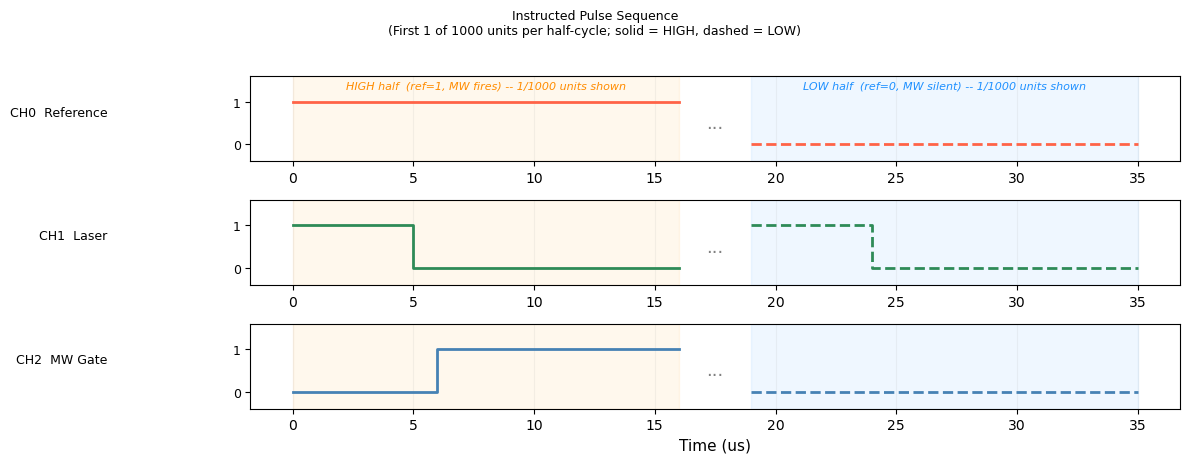

CH1: v min=81.200  max=85.800  mean=83.051
CH2: v min=-36.200  max=-28.040  mean=-32.811
CH3: v min=-32.800  max=-24.600  mean=-29.395


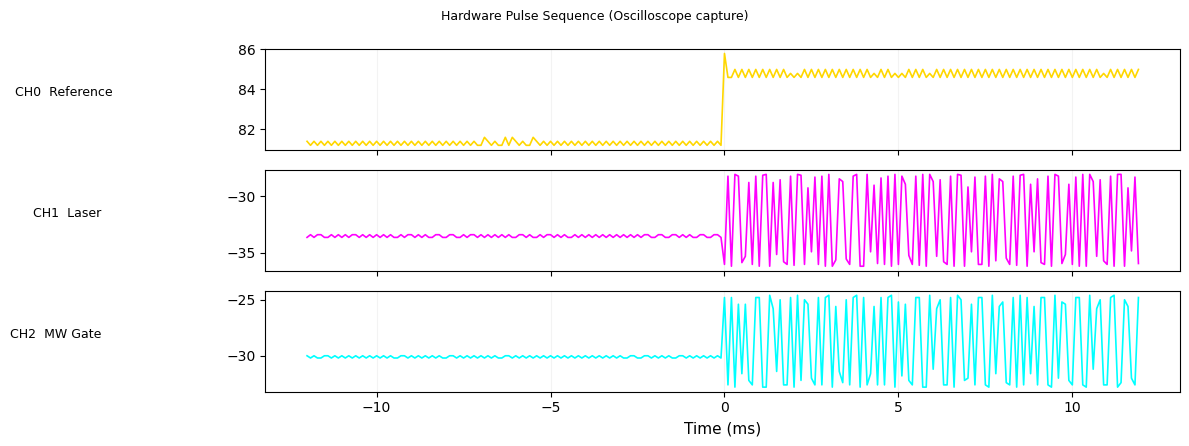

In [9]:
pulse_blaster.start_programming()
pb_log = PBLogger(pulse_blaster)   # wraps send_instruction; records every call

# ── HIGH HALF-CYCLE ───────────────────────────────────────────────────────────

# Step 1: Laser initializes spin into |0>_g via optical pumping.
start = pb_log.send(REF | LASER, 'CONTINUE', 0, Tlaser)

# Step 2: Pre-MW wait. Laser is OFF; MW not yet on.
#         Twait = Tunit - Tlaser - Tmw - Tpadding ensures unit timing sums correctly.
pb_log.send(REF, 'CONTINUE', 0, Twait)

# Step 3: MW ON. Drives |0>_g -> |+/-1>_g if frequency is resonant.
pb_log.send(REF | MW, 'CONTINUE', 0, Tmw)

# Step 4: LOOP instruction (= inter-unit Tpadding gap AND loop start).
#         Executes Nrepeat-1 times total (combined with Steps 5-7).
loop_high = pb_log.send(REF, 'LOOP', Nrepeat - 1, Tpadding)

# Steps 5-7: Loop body -- laser, wait, MW (same structure as Steps 1-3).
pb_log.send(REF | LASER, 'CONTINUE', 0, Tlaser)
pb_log.send(REF,         'CONTINUE', 0, Twait)
pb_log.send(REF | MW,    'END_LOOP', loop_high, Tmw)

# Step 8: Final Tpadding closes the last unit of the HIGH half.
pb_log.send(REF, 'CONTINUE', 0, Tpadding)

# ── LOW HALF-CYCLE ────────────────────────────────────────────────────────────

# Step 9: First laser pulse of LOW half (unrolled, outside loop).
pb_log.send(LASER, 'CONTINUE', 0, Tlaser)

# Step 10: LOOP -- fills the idle gap between laser pulses.
loop_low = pb_log.send(OFF, 'LOOP', Nrepeat - 1, Tunit - Tlaser)

# Step 11 (loop body): Laser ON again; MW stays silent.
pb_log.send(LASER, 'END_LOOP', loop_low, Tlaser)

# Step 12: Idle + BRANCH back to start for continuous looping.
pb_log.send(OFF, 'BRANCH', start, Tunit - Tlaser)

pulse_blaster.stop_programming()

# ───────────────────────────────────────────────────────────────────────────────
pb_log.plot_sequence(1)
pb_log.plot_capture('USB0::0x1AB1::0x04CE::DS1ZC232502790::INSTR', pulse_blaster)

#### SR830 config

In [10]:
# External reference from PulseBlaster CH0 wired to SR830 REF IN.
lock_in_amp.reference_source.set('external')
lock_in_amp.input_config('a') 
# lock_in_amp.input_config('I 1M')

# Template plot cells say: "lockin time constant = 30 ms"
# With lockin_settle_time = 0.2 s: 200 ms / 30 ms = 6.7 tau_c -> >99% settled.
tau_c = 30e-3
lock_in_amp.time_constant(tau_c)
lock_in_amp.sensitivity(500e-6)

lockin_settle_time = 0.2   # s — matches template exactly

print(f"Time constant : {tau_c*1e3:.0f} ms")
print(f"Settle time   : {lockin_settle_time*1e3:.0f} ms  ({lockin_settle_time/tau_c:.1f} tau_c)")

Time constant : 30 ms
Settle time   : 200 ms  (6.7 tau_c)


#### optimal params

In [11]:
class ODMRControlParams:
    """
    Computes optimal MW and lock-in control parameters for each frequency step.

    Physical references
    -------------------
    - Rabi frequency: Sewani et al. 2020, Sec. IV.C  (gamma_e = 28 GHz/T)
    - Antenna model:  Sewani et al. 2020, Fig. 2(e)   (Lorentzian, f0 = 2.49 GHz)
    - B1 calibration: Sewani et al. 2020, Fig. 2(d)   (306 uT at +24 dBm at resonance)
    - Lock-in ENBW:   ZI whitepaper, Table 1           (fNEP = 1/(4*tau_c) for n=1)
    - Settle time:    ZI whitepaper, Table 1           (99% settle = 4.61*tau_c for n=1)
    - Noise density:  SR830 spec, noted in notebook    (6 nV/sqrt(Hz))
    """

    GAMMA_E    = 28.0e9     # Hz/T   electron gyromagnetic ratio (Sewani 2020, Eq. 1)
    V_N        = 6.0e-9     # V/sqrt(Hz)  SR830 input noise density

    # Antenna parameters (Sewani et al. 2020, Fig. 2(e))
    F_ANT      = 2.49e9     # Hz  measured S11 minimum (resonance)
    BW_ANT     = 0.5e9      # Hz  estimated FWHM bandwidth from Fig. 2(e)
    P_REF_dBm  = 24.0       # dBm reference power level
    B1_PEAK    = 306.0e-6   # T   B1 field at resonance at P_REF

    def __init__(self, power_dBm, tau_c_s):
        """
        Parameters
        ----------
        power_dBm : float   MW output power in dBm (e.g. -6).
        tau_c_s   : float   Lock-in time constant in seconds (e.g. 30e-3).
        """
        self.power_dBm = power_dBm
        self.tau_c     = tau_c_s

    def antenna_gain(self, f_Hz):
        """
        Lorentzian power gain of antenna relative to its resonance peak (0..1).

        G(f) = (BW/2)^2 / ((f - f0)^2 + (BW/2)^2)

        Models the S11 Lorentzian shape from Sewani et al. 2020, Fig. 2(e).
        B1^2 (power) is proportional to G(f), so B1 scales as sqrt(G).
        """
        hw = self.BW_ANT / 2.0
        return hw**2 / ((f_Hz - self.F_ANT)**2 + hw**2)

    def B1(self, f_Hz):
        """
        Estimated oscillating B1 field at the diamond [T] for frequency f_Hz.

        B1(f, P) = B1_PEAK * 10^((P - P_ref)/20) * sqrt(G(f))

        The 10^((P-P_ref)/20) converts the dBm difference to a field (voltage)
        amplitude ratio. Source: Sewani et al. 2020, Sec. IV.C + Fig. 2(d).
        """
        field_ratio = 10.0 ** ((self.power_dBm - self.P_REF_dBm) / 20.0)
        return self.B1_PEAK * field_ratio * np.sqrt(self.antenna_gain(f_Hz))

    def rabi_freq(self, f_Hz):
        """
        Rabi frequency Omega_R [Hz] at f_Hz.

        Omega_R = (1/2) * gamma_e * B1(f)

        Source: Sewani et al. 2020, Sec. IV.C, text after Eq. (1).
        """
        return 0.5 * self.GAMMA_E * self.B1(f_Hz)

    def tau_pi(self, f_Hz):
        """
        Optimal pi-pulse duration [s] at f_Hz.

        tau_pi = 1 / (2 * Omega_R)

        This pulse length maximally inverts the spin population, maximizing
        ODMR contrast. Source: Sewani et al. 2020, Sec. V.B discussion of smw.
        """
        OR = self.rabi_freq(f_Hz)
        return 1.0 / (2.0 * OR) if OR > 0 else np.inf

    def enbw(self):
        """
        Equivalent noise-power bandwidth [Hz] for SR830 1st-order filter.

        fNEP = 1 / (4 * tau_c)

        Source: ZI whitepaper "Principles of lock-in detection", Table 1, n=1.
        """
        return 1.0 / (4.0 * self.tau_c)

    def settle_time_99pct(self):
        """
        Time [s] to settle to 99% of final value for 1st-order filter.

        lockin_settle_time(99%) = 4.61 * tau_c

        Source: ZI whitepaper, Table 1, n=1, "99%" column.
        """
        return 4.61 * self.tau_c

    def noise_rms(self):
        """
        RMS noise at SR830 output [V] within lock-in bandwidth.

        V_noise = V_n * sqrt(fNEP)

        where V_n = 6 nV/sqrt(Hz) is the SR830 input noise density.
        Source: ZI whitepaper, noise section; SR830 spec sheet.
        """
        return self.V_N * np.sqrt(self.enbw())

    def summary(self, f_Hz):
        b1   = self.B1(f_Hz)
        OR   = self.rabi_freq(f_Hz)
        tp   = self.tau_pi(f_Hz)
        enbw = self.enbw()
        t99  = self.settle_time_99pct()
        vn   = self.noise_rms()
        niceprint(
            f"**Optimal parameters for {f_Hz/1e9:.2f} GHz**  ──────────────────────────────────────────────── <br><br> "
            
            "$\\quad \\begin{array}{clll}"
            "\\textbf{Param} & \\textbf{Value} & \\textbf{Formula} & \\textbf{Source} \\\\"
            "\\hline"
            f" f                              & = {f_Hz/1e9:.4f}\\; {{\\rm GHz}} & &\\\\"
            f" B_1                            & = {b1*1e6:.3f}\\;   \\mu T       &                                  &{{\\rm Sewani\\; Fig.\\; 2(d)\\; model}} \\\\"
            f" \\Omega_R                      & = {OR/1e3:.2f}\\;   {{\\rm kHz}} & \\frac{{1}}{{2}} \\gamma_e B_1 &\\\\"
            f" \\tau_\\pi                     & = {tp*1e6:.2f}\\;   \\mu s       & \\frac{{1}}{{2\\Omega_R}}      &\\\\"
            f" ENBW                           & = {enbw:.2f}\\;     {{\\rm Hz}}  & \\frac{{1}}{{4\\tau_c}}        &{{\\rm ZI\\; Table\\; 1}} \\\\"
            f" t_{{\\rm settle}}              & = {t99*1e3:.1f}\\;  {{\\rm ms}}  & 4.61\\tau_c                    &{{\\rm ZI\\; Table\\; 1}} \\\\"
            f" {{\\rm RMS }} V_{{\\rm noise}} & = {vn*1e9:.2f}\\;   {{\\rm nV}}  & \\frac{{6 \\;nV}}{{\\sqrt{{\\rm Hz}}}} \\sqrt{{\\rm ENBW}} &\\\\"
            "\\end{array}$ <br><br>"
        )



In [12]:
ctrl = ODMRControlParams(power_dBm=mwpower, tau_c_s=tau_c)
ctrl.summary(2.87e9)

niceprint('---')
print(f"Current Tmw = {Tmw/1e3:.1f} us")
print(f"Optimal tau_pi at 2.87 GHz = {ctrl.tau_pi(2.87e9)*1e6:.2f} us")
print(f"(Difference = {(Tmw/1e3 - ctrl.tau_pi(2.87e9)*1e6):.2f} us)")

**Optimal parameters for 2.87 GHz**  ──────────────────────────────────────────────── <br><br> $\quad \begin{array}{clll}\textbf{Param} & \textbf{Value} & \textbf{Formula} & \textbf{Source} \\\hline f                              & = 2.8700\; {\rm GHz} & &\\ B_1                            & = 5.318\;   \mu T       &                                  &{\rm Sewani\; Fig.\; 2(d)\; model} \\ \Omega_R                      & = 74.46\;   {\rm kHz} & \frac{1}{2} \gamma_e B_1 &\\ \tau_\pi                     & = 6.72\;   \mu s       & \frac{1}{2\Omega_R}      &\\ ENBW                           & = 8.33\;     {\rm Hz}  & \frac{1}{4\tau_c}        &{\rm ZI\; Table\; 1} \\ t_{\rm settle}              & = 138.3\;  {\rm ms}  & 4.61\tau_c                    &{\rm ZI\; Table\; 1} \\ {\rm RMS } V_{\rm noise} & = 17.32\;   {\rm nV}  & \frac{6 \;nV}{\sqrt{\rm Hz}} \sqrt{\rm ENBW} &\\\end{array}$ <br><br>

---

Current Tmw = 10.0 us
Optimal tau_pi at 2.87 GHz = 6.72 us
(Difference = 3.28 us)


#### qcodes setup

In [13]:
MW_freq = qc.ManualParameter('mw_frequency', unit='Hz')
LI_R    = qc.ManualParameter('signal',       unit='V')

initialise_or_create_database_at(Path.cwd() / 'ODMR_Lab.db')

experiment = load_or_create_experiment(
    experiment_name='ODMR_Spectrum',
    sample_name='NV_diamond',
)

meas = Measurement(exp=experiment, name='zero_field_ODMR')
meas.register_parameter(MW_freq)
meas.register_parameter(LI_R, setpoints=(MW_freq,))

#### negative test

=== Negative Test (MW OFF) ===
Mean R           : 438249.25 nV
Std R (noise)    : 129282.53 nV
Theoretical floor: 17.32 nV  (ZI whitepaper, Table 1)
SNR check: if a real ODMR peak appears here, check for MW leakage.


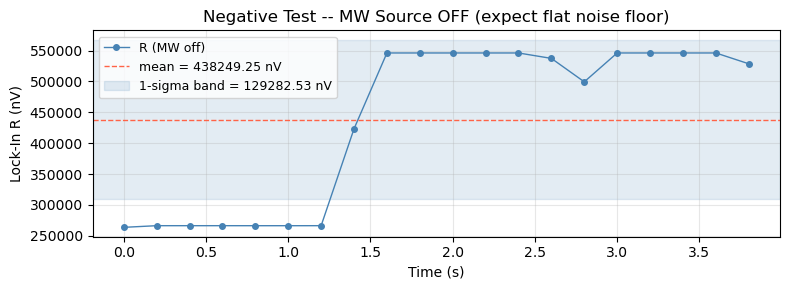

In [14]:
# ── Negative test: MW source OFF, PulseBlaster running ────────────────────────
# Expected: R is flat at the noise floor (~17 nV). No ODMR dip.
# This validates the lock-in reference lock and gives the empirical noise floor.

N_neg = 20
pulse_blaster.start()
sleep(0.1)
# microwave_src.output('ON') is intentionally NOT called here.

neg_readings = []
for i in range(N_neg):
    sleep(lockin_settle_time)
    neg_readings.append(lock_in_amp.R())

pulse_blaster.stop()

neg_arr  = np.array(neg_readings)
neg_mean = neg_arr.mean()
neg_std  = neg_arr.std()

print("=== Negative Test (MW OFF) ===")
print(f"Mean R           : {neg_mean*1e9:.2f} nV")
print(f"Std R (noise)    : {neg_std*1e9:.2f} nV")
print(f"Theoretical floor: {ctrl.noise_rms()*1e9:.2f} nV  (ZI whitepaper, Table 1)")
print(f"SNR check: if a real ODMR peak appears here, check for MW leakage.")

fig, ax = plt.subplots(figsize=(8, 3))
t_neg = np.arange(N_neg) * lockin_settle_time
ax.plot(t_neg, neg_arr * 1e9, 'o-', ms=4, lw=1, color='steelblue', label='R (MW off)')
ax.axhline(neg_mean * 1e9, color='tomato', ls='--', lw=1,
           label=f'mean = {neg_mean*1e9:.2f} nV')
ax.axhspan((neg_mean - neg_std) * 1e9, (neg_mean + neg_std) * 1e9,
           alpha=0.15, color='steelblue', label=f'1-sigma band = {neg_std*1e9:.2f} nV')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Lock-In R (nV)')
ax.set_title('Negative Test -- MW Source OFF (expect flat noise floor)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### coarse sweep

params

In [15]:
# ── Phase 1: coarse sweep to locate the ODMR peak ─────────────────────────────
# Sewani et al. 2020, Fig. 4(b): zero-field peak at D = 2.87 GHz.
# Step = 6.25 MHz < FWHM (~14 MHz), so the peak will be resolved.

f1_start  = 2.77e9    # Hz  (template: freq_min = 2.77 GHz)
f1_stop   = 2.97e9    # Hz  (template: freq_max = 2.97 GHz)
n1_pts    = 32

freq_list_1        = np.linspace(f1_start, f1_stop, n1_pts)
idx1_rand          = np.random.permutation(n1_pts)
freq_list_1_rand   = freq_list_1[idx1_rand]   # randomized order for MW settling

step_1_MHz = (f1_stop - f1_start) / (n1_pts - 1) / 1e6
print(f"Phase 1: {f1_start/1e9:.2f} to {f1_stop/1e9:.2f} GHz")
print(f"Step   : {step_1_MHz:.2f} MHz  ({n1_pts} pts)")
print(f"Total  : ~{n1_pts * lockin_settle_time:.0f} s  (randomized order)")

Phase 1: 2.77 to 2.97 GHz
Step   : 6.45 MHz  (32 pts)
Total  : ~6 s  (randomized order)


run sweep

In [16]:
# ── Phase 1 sweep ──────────────────────────────────────────────────────────────
meas1 = Measurement(exp=experiment, name='zero_field_ODMR_coarse')
meas1.register_parameter(MW_freq)
meas1.register_parameter(LI_R, setpoints=(MW_freq,))

pulse_blaster.start()
sleep(0.1)
microwave_src.output('ON')

r1_dict = {}
with meas1.run() as datasaver1:
    for f_mw in tqdm_bar(freq_list_1_rand, desc='Phase 1 (coarse)', unit='pt'):
        microwave_src.frequency(f_mw)
        sleep(lockin_settle_time)
        r_val = lock_in_amp.R()
        r1_dict[f_mw] = r_val
        datasaver1.add_result((MW_freq, f_mw), (LI_R, r_val))

microwave_src.output('OFF')
pulse_blaster.stop()

# Sort results back to frequency order for fitting.
r1_arr = np.array([r1_dict[f] for f in freq_list_1])
print(f"Phase 1 done. Run ID: {datasaver1.dataset.run_id}")

Starting experimental run with id: 43. 


Phase 1 (coarse):   0%|          | 0/32 [00:00<?, ?pt/s]

Phase 1 done. Run ID: 43


##### locate peak

Phase 1 fit:  f0 = 2.8238 GHz,  FWHM = 583.9 MHz


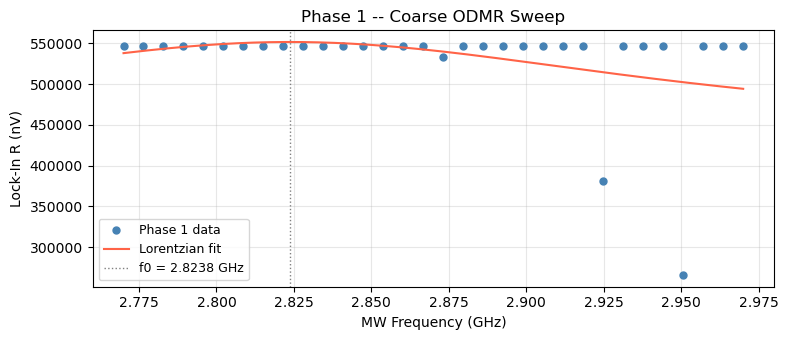

In [17]:
# ── Fit Phase 1 data to locate peak center ────────────────────────────────────
def lorentzian(f, f0, gamma, A, C):
    return C - A * (gamma / 2)**2 / ((f - f0)**2 + (gamma / 2)**2)

p0_1 = [2.87e9, 20e6, r1_arr.max() - r1_arr.min(), r1_arr.min()]
try:
    popt_1, _ = curve_fit(lorentzian, freq_list_1, r1_arr, p0=p0_1, maxfev=5000)
    f0_coarse    = popt_1[0]
    gamma_coarse = abs(popt_1[1])
    print(f"Phase 1 fit:  f0 = {f0_coarse/1e9:.4f} GHz,  FWHM = {2*gamma_coarse/1e6:.1f} MHz")
except RuntimeError:
    f0_coarse    = freq_list_1[np.argmax(r1_arr)]
    gamma_coarse = 20e6
    popt_1       = None
    print(f"Fit failed; using argmax: f0 = {f0_coarse/1e9:.4f} GHz")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(freq_list_1 / 1e9, r1_arr * 1e9, 'o', ms=5, color='steelblue', label='Phase 1 data')
if popt_1 is not None:
    f_fine_1 = np.linspace(freq_list_1.min(), freq_list_1.max(), 500)
    ax.plot(f_fine_1 / 1e9, lorentzian(f_fine_1, *popt_1) * 1e9,
            color='tomato', lw=1.5, label='Lorentzian fit')
ax.axvline(f0_coarse / 1e9, color='gray', ls=':', lw=1, label=f'f0 = {f0_coarse/1e9:.4f} GHz')
ax.set_xlabel('MW Frequency (GHz)')
ax.set_ylabel('Lock-In R (nV)')
ax.set_title('Phase 1 -- Coarse ODMR Sweep')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### fine sweep

params

In [18]:
# ── Phase 2: fine sweep centered on the peak found in Phase 1 ─────────────────
window_Hz  = 3 * (2.0 * gamma_coarse)   # +/- 3*FWHM window
f2_start   = max(f0_coarse - window_Hz, f1_start)
f2_stop    = min(f0_coarse + window_Hz, f1_stop)
n2_pts     = 128

freq_list_2      = np.linspace(f2_start, f2_stop, n2_pts)
idx2_rand        = np.random.permutation(n2_pts)
freq_list_2_rand = freq_list_2[idx2_rand]

step_2_MHz = (f2_stop - f2_start) / (n2_pts - 1) / 1e6
print(f"Phase 2: {f2_start/1e9:.4f} to {f2_stop/1e9:.4f} GHz")
print(f"Step   : {step_2_MHz:.3f} MHz  ({n2_pts} pts)")
print(f"Total  : ~{n2_pts * lockin_settle_time:.0f} s  (randomized order)")

# Print optimal tau_pi for each Phase 2 frequency step.
print("\n=== Optimal tau_pi per Phase 2 frequency step ===")
print(f"{'f (GHz)':>10}  {'B1 (uT)':>8}  {'Omega_R (kHz)':>14}  {'tau_pi (us)':>12}")
sample_idx = np.linspace(0, n2_pts - 1, 8, dtype=int)
for i in sample_idx:
    f = freq_list_2[i]
    b1 = ctrl.B1(f)
    OR = ctrl.rabi_freq(f)
    tp = ctrl.tau_pi(f)
    print(f"{f/1e9:>10.4f}  {b1*1e6:>8.2f}  {OR/1e3:>14.2f}  {tp*1e6:>12.2f}")
print(f"\nCurrent Tmw = {Tmw/1e3:.1f} us (fixed for all steps in this sequence)")

Phase 2: 2.7700 to 2.9700 GHz
Step   : 1.575 MHz  (128 pts)
Total  : ~26 s  (randomized order)

=== Optimal tau_pi per Phase 2 frequency step ===
   f (GHz)   B1 (uT)   Omega_R (kHz)   tau_pi (us)
    2.7700      6.44           90.23          5.54
    2.7983      6.09           85.32          5.86
    2.8267      5.77           80.76          6.19
    2.8550      5.47           76.55          6.53
    2.8834      5.19           72.66          6.88
    2.9117      4.93           69.08          7.24
    2.9401      4.70           65.78          7.60
    2.9700      4.47           62.58          7.99

Current Tmw = 10.0 us (fixed for all steps in this sequence)


run sweep

In [19]:
# ── Phase 2 sweep ──────────────────────────────────────────────────────────────
meas2 = Measurement(exp=experiment, name='zero_field_ODMR_fine')
meas2.register_parameter(MW_freq)
meas2.register_parameter(LI_R, setpoints=(MW_freq,))

pulse_blaster.start()
sleep(0.1)
microwave_src.output('ON')

r2_dict = {}
with meas2.run() as datasaver2:
    for f_mw in tqdm_bar(freq_list_2_rand, desc='Phase 2 (fine)', unit='pt'):
        microwave_src.frequency(f_mw)
        sleep(lockin_settle_time)
        r_val = lock_in_amp.R()
        r2_dict[f_mw] = r_val
        datasaver2.add_result((MW_freq, f_mw), (LI_R, r_val))

microwave_src.output('OFF')
pulse_blaster.stop()

r2_arr = np.array([r2_dict[f] for f in freq_list_2])
print(f"Phase 2 done. Run ID: {datasaver2.dataset.run_id}")

Starting experimental run with id: 44. 


Phase 2 (fine):   0%|          | 0/128 [00:00<?, ?pt/s]

Phase 2 done. Run ID: 44


##### fit peak

=== Measurement Accuracy ===
Peak center f0    : 2.81724 +/- 0.194 MHz
FWHM              : 0.28 +/- 0.03 MHz
Amplitude A       : 303551.08 nV
Noise floor (meas): 0.00 nV  (off-resonance std of data)
Noise floor (theo): 17.32 nV  (ZI whitepaper Table 1)
Peak SNR          : 933254834498294.4
Freq. step        : 1.575 MHz
Points per FWHM   : 0.2
Freq. precision   : 0.194 MHz  (1-sigma from covariance)
Contrast C        : 55.59 %  (= A / baseline)


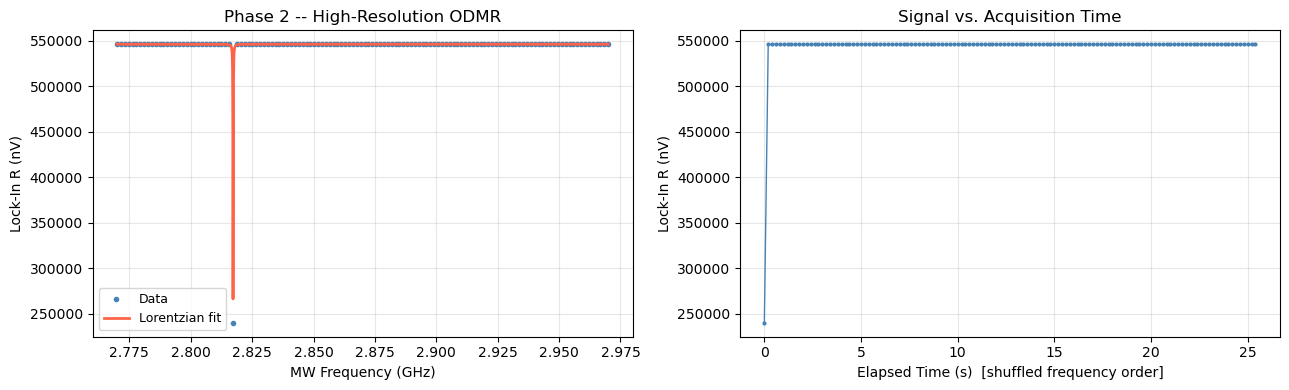

In [20]:
# ── Lorentzian fit to Phase 2 ─────────────────────────────────────────────────
f_arr_2 = freq_list_2
r_arr_2 = r2_arr
f_lo, f_hi = f_arr_2.min(), f_arr_2.max()
sig_range   = r_arr_2.max() - r_arr_2.min()
lower = [f_lo,  1e4,   0,             r_arr_2.min() - sig_range]
upper = [f_hi,  100e6, sig_range * 2, r_arr_2.max() + sig_range]

p0_2 = [f0_coarse, gamma_coarse, r_arr_2.max() - r_arr_2.min(), r_arr_2.min()]
p0_2 = [float(np.clip(p, lo, hi)) for p, lo, hi in zip(p0_2, lower, upper)]

popt_2, pcov_2 = curve_fit(
    lorentzian, f_arr_2, r_arr_2,
    p0     = p0_2,
    bounds = (lower, upper),
    maxfev = 50000,
)
f0_fit, gamma_fit, A_fit, C_fit = popt_2
perr_2 = np.sqrt(np.diag(pcov_2))

# Noise floor: std of points outside +/- 2*FWHM from the fitted peak.
off_mask = np.abs(f_arr_2 - f0_fit) > 2.0 * (2.0 * gamma_fit)
noise_empirical = r_arr_2[off_mask].std() if off_mask.sum() >= 3 else ctrl.noise_rms()

# Measurement accuracy summary.
print("=== Measurement Accuracy ===")
print(f"Peak center f0    : {f0_fit/1e9:.5f} +/- {perr_2[0]/1e6:.3f} MHz")
print(f"FWHM              : {2*gamma_fit/1e6:.2f} +/- {2*perr_2[1]/1e6:.2f} MHz")
print(f"Amplitude A       : {A_fit*1e9:.2f} nV")
print(f"Noise floor (meas): {noise_empirical*1e9:.2f} nV  (off-resonance std of data)")
print(f"Noise floor (theo): {ctrl.noise_rms()*1e9:.2f} nV  (ZI whitepaper Table 1)")
print(f"Peak SNR          : {A_fit/noise_empirical:.1f}")
print(f"Freq. step        : {step_2_MHz:.3f} MHz")
print(f"Points per FWHM   : {2*gamma_fit/(step_2_MHz*1e6):.1f}")
print(f"Freq. precision   : {perr_2[0]/1e6:.3f} MHz  (1-sigma from covariance)")
print(f"Contrast C        : {A_fit/abs(C_fit)*100:.2f} %  (= A / baseline)")

f_fine_2 = np.linspace(f_arr_2.min(), f_arr_2.max(), 2000)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: spectrum + Lorentzian fit.
axes[0].plot(f_arr_2 / 1e9, r_arr_2 * 1e9 , 'o', ms=3, color='steelblue', label='Data')
axes[0].plot(f_fine_2 / 1e9, lorentzian(f_fine_2, *popt_2) * 1e9,
             color='tomato', lw=2, label='Lorentzian fit')
axes[0].set_xlabel('MW Frequency (GHz)')
axes[0].set_ylabel('Lock-In R (nV)')
axes[0].set_title('Phase 2 -- High-Resolution ODMR')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: signal vs. acquisition time in shuffled frequency order.
# A flat or slowly varying trace here means no systematic drift.
r2_timeorder = np.array([r2_dict[freq_list_2_rand[i]] for i in range(n2_pts)])
t_acq = np.arange(n2_pts) * lockin_settle_time
axes[1].plot(t_acq, r2_timeorder * 1e9, lw=1, marker='o', ms=2, color='steelblue')
axes[1].set_xlabel('Elapsed Time (s)  [shuffled frequency order]')
axes[1].set_ylabel('Lock-In R (nV)')
axes[1].set_title('Signal vs. Acquisition Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### zoom sweep

In [21]:
# ── Phase 3: ultra-fine sweep centered on Phase 2 fitted peak ─────────────────
window_3_Hz = 2.0 * gamma_fit          # +/- 1 FWHM around the fitted center
f3_start    = max(f0_fit - window_3_Hz, f1_start)
f3_stop     = min(f0_fit + window_3_Hz, f1_stop)
n3_pts      = 128

freq_list_3      = np.linspace(f3_start, f3_stop, n3_pts)
idx3_rand        = np.random.permutation(n3_pts)
freq_list_3_rand = freq_list_3[idx3_rand]

step_3_MHz = (f3_stop - f3_start) / (n3_pts - 1) / 1e6
print(f"Phase 3: {f3_start/1e9:.5f} to {f3_stop/1e9:.5f} GHz")
print(f"Step   : {step_3_MHz:.4f} MHz  ({n3_pts} pts)")
print(f"Total  : ~{n3_pts * lockin_settle_time:.0f} s  (randomized order)")

# ── Phase 3 sweep ──────────────────────────────────────────────────────────────
meas3 = Measurement(exp=experiment, name='zero_field_ODMR_ultrafine')
meas3.register_parameter(MW_freq)
meas3.register_parameter(LI_R, setpoints=(MW_freq,))

pulse_blaster.start()
sleep(0.1)
microwave_src.output('ON')

r3_dict = {}
with meas3.run() as datasaver3:
    for f_mw in tqdm_bar(freq_list_3_rand, desc='Phase 3 (ultra-fine)', unit='pt'):
        microwave_src.frequency(f_mw)
        sleep(lockin_settle_time)
        r_val = lock_in_amp.R()
        r3_dict[f_mw] = r_val
        datasaver3.add_result((MW_freq, f_mw), (LI_R, r_val))

microwave_src.output('OFF')
pulse_blaster.stop()

r3_arr = np.array([r3_dict[f] for f in freq_list_3])
print(f"Phase 3 done. Run ID: {datasaver3.dataset.run_id}")

Phase 3: 2.81696 to 2.81753 GHz
Step   : 0.0045 MHz  (128 pts)
Total  : ~26 s  (randomized order)
Starting experimental run with id: 45. 


Phase 3 (ultra-fine):   0%|          | 0/128 [00:00<?, ?pt/s]

Phase 3 done. Run ID: 45


##### fit peak

=== Phase 3 Measurement Accuracy ===
Peak center f0    : 2.817335 +/- 0.0064 MHz
FWHM              : 0.079 +/- 0.041 MHz
Amplitude A       : 40994.22 nV
Noise floor (meas): 12763.25 nV  (off-resonance std of data)
Noise floor (theo): 17.32 nV  (ZI whitepaper Table 1)
Peak SNR          : 3.2
Freq. step        : 0.0045 MHz
Points per FWHM   : 17.9
Freq. precision   : 0.0064 MHz  (1-sigma from covariance)
Contrast C        : 7.49 %  (= A / baseline)


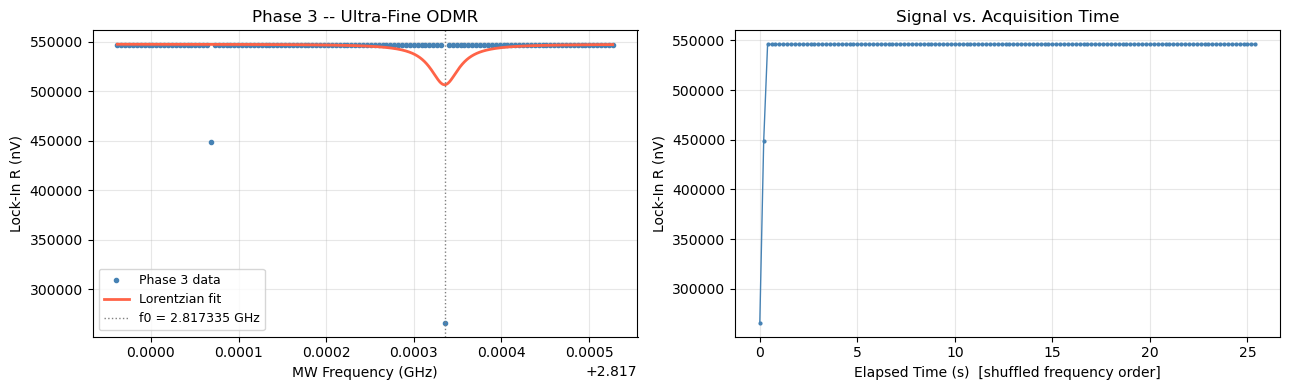

In [22]:
# ── Lorentzian fit to Phase 3 ─────────────────────────────────────────────────
f_arr_3   = freq_list_3
r_arr_3   = r3_arr
f_lo_3    = f_arr_3.min()
f_hi_3    = f_arr_3.max()
sig_range_3 = r_arr_3.max() - r_arr_3.min()

lower_3 = [f_lo_3, 1e4,   0,               r_arr_3.min() - sig_range_3]
upper_3 = [f_hi_3, 100e6, sig_range_3 * 2, r_arr_3.max() + sig_range_3]

p0_3 = [f0_fit, gamma_fit, sig_range_3, r_arr_3.max()]
p0_3 = [float(np.clip(p, lo, hi)) for p, lo, hi in zip(p0_3, lower_3, upper_3)]

popt_3, pcov_3 = curve_fit(
    lorentzian, f_arr_3, r_arr_3,
    p0     = p0_3,
    bounds = (lower_3, upper_3),
    maxfev = 50000,
)
f0_fit3, gamma_fit3, A_fit3, C_fit3 = popt_3
perr_3 = np.sqrt(np.diag(pcov_3))

off_mask_3      = np.abs(f_arr_3 - f0_fit3) > 2.0 * (2.0 * gamma_fit3)
noise_empirical3 = r_arr_3[off_mask_3].std() if off_mask_3.sum() >= 3 else ctrl.noise_rms()

print("=== Phase 3 Measurement Accuracy ===")
print(f"Peak center f0    : {f0_fit3/1e9:.6f} +/- {perr_3[0]/1e6:.4f} MHz")
print(f"FWHM              : {2*gamma_fit3/1e6:.3f} +/- {2*perr_3[1]/1e6:.3f} MHz")
print(f"Amplitude A       : {A_fit3*1e9:.2f} nV")
print(f"Noise floor (meas): {noise_empirical3*1e9:.2f} nV  (off-resonance std of data)")
print(f"Noise floor (theo): {ctrl.noise_rms()*1e9:.2f} nV  (ZI whitepaper Table 1)")
print(f"Peak SNR          : {A_fit3/noise_empirical3:.1f}")
print(f"Freq. step        : {step_3_MHz:.4f} MHz")
print(f"Points per FWHM   : {2*gamma_fit3/(step_3_MHz*1e6):.1f}")
print(f"Freq. precision   : {perr_3[0]/1e6:.4f} MHz  (1-sigma from covariance)")
print(f"Contrast C        : {A_fit3/abs(C_fit3)*100:.2f} %  (= A / baseline)")

f_fine_3 = np.linspace(f_arr_3.min(), f_arr_3.max(), 2000)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(f_arr_3 / 1e9, r_arr_3 * 1e9, 'o', ms=3, color='steelblue', label='Phase 3 data')
axes[0].plot(f_fine_3 / 1e9, lorentzian(f_fine_3, *popt_3) * 1e9,
             color='tomato', lw=2, label='Lorentzian fit')
axes[0].axvline(f0_fit3 / 1e9, color='gray', ls=':', lw=1,
                label=f'f0 = {f0_fit3/1e9:.6f} GHz')
axes[0].set_xlabel('MW Frequency (GHz)')
axes[0].set_ylabel('Lock-In R (nV)')
axes[0].set_title('Phase 3 -- Ultra-Fine ODMR')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

r3_timeorder = np.array([r3_dict[freq_list_3_rand[i]] for i in range(n3_pts)])
t_acq3 = np.arange(n3_pts) * lockin_settle_time
axes[1].plot(t_acq3, r3_timeorder * 1e9, lw=1, marker='o', ms=2, color='steelblue')
axes[1].set_xlabel('Elapsed Time (s)  [shuffled frequency order]')
axes[1].set_ylabel('Lock-In R (nV)')
axes[1].set_title('Signal vs. Acquisition Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### end